# CNN Spatio-Temporal Stream — Deepfake Detection

## Two-Stream Late Fusion Architecture (Stream 2 of 2)

This notebook implements a **research-grade Spatio-Temporal CNN** using EfficientNet-B4 backbone with **BiLSTM Temporal Aggregation** for deepfake detection.

### Key Research Contributions:

1. **Temporal Modeling (BiLSTM + Multi-Head Attention)**
   - Unlike naive frame averaging, we model inter-frame dependencies
   - Detects temporal flickering, blending shifts, and motion anomalies
   - Enables detection of GAN/Diffusion artifacts that manifest across frames

2. **Grad-CAM Visualization**
   - Provides visual proof of what the model learns
   - Shows attention on facial regions (jawline, eyes, blending boundaries)
   - Essential for research paper methodology section

```
┌──────────────────────────────────────────────────────────────────────────────┐
│                    SPATIO-TEMPORAL ARCHITECTURE                              │
├──────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│   Video (T frames) ──→ MTCNN Face Detection ──→ T × (224, 224, 3) crops     │
│                                                                              │
│   ┌─────────────────────────────────────────────────────────────────────┐   │
│   │  SPATIAL FEATURE EXTRACTION                                          │   │
│   │  EfficientNet-B4 (pretrained, 1792-dim features per frame)          │   │
│   │                                                                      │   │
│   │      Frame 1 ──→ [f₁]                                               │   │
│   │      Frame 2 ──→ [f₂]     ──→ Feature Sequence (T × 1792)           │   │
│   │      ...                                                             │   │
│   │      Frame T ──→ [fₜ]                                               │   │
│   └─────────────────────────────────────────────────────────────────────┘   │
│                              ↓                                               │
│   ┌─────────────────────────────────────────────────────────────────────┐   │
│   │  TEMPORAL AGGREGATION (BiLSTM + Multi-Head Attention)               │   │
│   │                                                                      │   │
│   │  [f₁, f₂, ..., fₜ] ──→ BiLSTM (2-layer, bidirectional)              │   │
│   │                                ↓                                     │   │
│   │                    Multi-Head Self-Attention (4 heads)               │   │
│   │                                ↓                                     │   │
│   │                    Weighted Temporal Pooling                         │   │
│   │                                ↓                                     │   │
│   │                    Video-Level Representation (512-dim)              │   │
│   └─────────────────────────────────────────────────────────────────────┘   │
│                              ↓                                               │
│   ┌─────────────────────────────────────────────────────────────────────┐   │
│   │  CLASSIFIER                                                          │   │
│   │  Linear(512 → 256) → BatchNorm → GELU → Dropout                     │   │
│   │  Linear(256 → 128) → BatchNorm → GELU → Dropout                     │   │
│   │  Linear(128 → 1) → Sigmoid                                          │   │
│   │                        ↓                                             │   │
│   │                    P_CNN (0 = Real, 1 = Fake)                        │   │
│   └─────────────────────────────────────────────────────────────────────┘   │
│                                                                              │
└──────────────────────────────────────────────────────────────────────────────┘

                    ↓ LATE FUSION ↓

        P_final = w₁ × P_CNN + w₂ × P_rPPG (from Stream 1)
```

**Output:** `cnn_predictions.csv` with video-level P_CNN scores for Late Fusion

In [ ]:
import os

root = "/kaggle/input"

for current_path, dirs, files in os.walk(root):
    level = current_path.replace(root, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(current_path)}/")

## 1. Setup & Imports

In [ ]:
!pip install "numpy<2" --force-reinstall

In [ ]:
!pip install timm==0.9.16 transformers==4.38.2 --force-reinstall

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# INSTALL DEPENDENCIES
# ═══════════════════════════════════════════════════════════════════════════════

import subprocess
import sys

def install_packages():
    packages = [
        "facenet-pytorch",
        "timm==0.9.16",
        "albumentations>=1.4.0,<2.0.0",
        "seaborn>=0.12.0",
        "opencv-python-headless",
    ]
    for pkg in packages:
        print(f"Installing {pkg}...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)
    print("✓ All packages installed")

install_packages()

DATA LOADING

In [18]:
# ═══════════════════════════════════════════════════════════════════════
# UNIFIED DATA COMPILER — Run ONCE before all other cells
# Creates master_dataset_index.csv used by both CNN + rPPG notebooks
# Guarantees: alignment, balance, P100-safe RAM, no metadata bottleneck
# ═══════════════════════════════════════════════════════════════════════

import os, json, random
import pandas as pd
random.seed(42)

OUTPUT_CSV    = "/kaggle/working/master_dataset_index.csv"
VIDEO_EXTS    = ('.mp4', '.avi', '.mov', '.mkv', '.webm')
MAX_PER_CLASS = 200  # per source — keeps total ~1600 videos, safe for P100

def scan_folder(folder, label, source, max_n=MAX_PER_CLASS):
    if not os.path.exists(folder):
        print(f"  ⚠️  NOT FOUND: {folder}")
        return []
    # FIXED: os.walk() is recursive — finds videos in subdirectories
    files = []
    for root, dirs, fnames in os.walk(folder):
        for f in fnames:
            if f.lower().endswith(VIDEO_EXTS):
                files.append(os.path.join(root, f))
    files = sorted(files)
    if len(files) > max_n:
        files = random.sample(files, max_n)
    # FIXED: use relative path in video_id to prevent basename collisions
    records = [{'video_id': f"{source}__{os.path.relpath(f, folder).replace(os.sep, '_')}",
                'path':     f,
                'label':    label,
                'source':   source} for f in files]
    print(f"  ✓ {source:30s} | label={label} | {len(records):4d} videos")
    return records

# ── MUST initialize all_records BEFORE any scan calls ────────────────
all_records = []

# ── 1. FaceForensics++ ───────────────────────────────────────────────
print("\n── FaceForensics++ ─────────────────────────────────────────────")
FF_BASE = "/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23"
all_records += scan_folder(f"{FF_BASE}/original",          0, "FF_real")
all_records += scan_folder(f"{FF_BASE}/Deepfakes",         1, "FF_Deepfakes")
all_records += scan_folder(f"{FF_BASE}/Face2Face",         1, "FF_Face2Face")
all_records += scan_folder(f"{FF_BASE}/FaceSwap",          1, "FF_FaceSwap")
all_records += scan_folder(f"{FF_BASE}/NeuralTextures",    1, "FF_NeuralTextures")
all_records += scan_folder(f"{FF_BASE}/FaceShifter",       1, "FF_FaceShifter")
# FIXED: DeepFakeDetection now placed AFTER initialization, in correct position
all_records += scan_folder(f"{FF_BASE}/DeepFakeDetection", 1, "FF_DeepFakeDetection")

# ── 2. Celeb-DF v2 ───────────────────────────────────────────────────
print("\n── Celeb-DF v2 ─────────────────────────────────────────────────")
CELEB_BASE = "/kaggle/input/datasets/reubensuju/celeb-df-v2"
all_records += scan_folder(f"{CELEB_BASE}/Celeb-real",      0, "Celeb_real",  max_n=150)
all_records += scan_folder(f"{CELEB_BASE}/YouTube-real",    0, "YT_real",     max_n=50)
all_records += scan_folder(f"{CELEB_BASE}/Celeb-synthesis", 1, "Celeb_fake",  max_n=200)

# ── 3. Custom Dataset (lalith023) ────────────────────────────────────
print("\n── Custom Dataset (400 Videos) ─────────────────────────────────")
CUSTOM_BASE = "/kaggle/input/datasets/lalith023/400videos/content/drive/MyDrive/face_dataset_dip"
all_records += scan_folder(f"{CUSTOM_BASE}/real_videos",     0, "Custom_real", max_n=400)
all_records += scan_folder(f"{CUSTOM_BASE}/deepfake_videos", 1, "Custom_fake", max_n=400)

# ── 4. DFDC ──────────────────────────────────────────────────────────
print("\n── DFDC ────────────────────────────────────────────────────────")
DFDC_DIR = "/kaggle/input/datasets/lalith023/dfdc-sample-videos"
dfdc_real, dfdc_fake = [], []
if os.path.exists(DFDC_DIR):
    meta_path = os.path.join(DFDC_DIR, "metadata.json")
    if os.path.exists(meta_path):
        with open(meta_path, 'r') as f:
            meta = json.load(f)
        for filename, info in meta.items():
            path = os.path.join(DFDC_DIR, filename)
            if not os.path.exists(path):
                continue
            rec = {'video_id': f"DFDC__{filename}",
                   'path':     path,
                   'label':    1 if info['label'] == 'FAKE' else 0,
                   'source':   'DFDC'}
            if info['label'] == 'REAL':
                dfdc_real.append(rec)
            else:
                dfdc_fake.append(rec)
        n = len(dfdc_real)
        all_records += dfdc_real
        all_records += random.sample(dfdc_fake, min(n, len(dfdc_fake)))
        print(f"  ✓ {'DFDC':30s} | real={n} | fake={n}")
    else:
        print(f"  ⚠️  metadata.json not found in {DFDC_DIR}")
else:
    print(f"  ⚠️  DFDC dir not found: {DFDC_DIR}")

# Guard: fail loudly if data is critically missing
assert len(all_records) >= 100, \
    f"FATAL: Only {len(all_records)} total videos found — check all dataset paths above!"
n_real_pre = sum(1 for r in all_records if r['label'] == 0)
n_fake_pre = sum(1 for r in all_records if r['label'] == 1)
assert n_real_pre >= 50, f"FATAL: Only {n_real_pre} real videos — check real dataset paths!"
assert n_fake_pre >= 50, f"FATAL: Only {n_fake_pre} fake videos — check fake dataset paths!"

# ── Balance real vs fake globally ────────────────────────────────────
df     = pd.DataFrame(all_records)
n_real = len(df[df['label'] == 0])
n_fake = len(df[df['label'] == 1])
print(f"\n── Pre-balance ─────────────────────────────────────────────────")
print(f"  Real : {n_real}")
print(f"  Fake : {n_fake}")

min_n = min(n_real, n_fake)

print(f"\n  ⚠️  Balancing discarded {n_fake - min_n} fake samples ({n_fake - min_n} of {n_fake} = {100*(n_fake-min_n)/n_fake:.0f}%)")
print(f"  Consider using class weighting instead to retain all {n_fake} fakes.")

df    = pd.concat([
    df[df['label'] == 0].sample(min_n, random_state=42),
    df[df['label'] == 1].sample(min_n, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

# ── Verify every path actually exists ────────────────────────────────
missing = df[~df['path'].apply(os.path.exists)]
if len(missing) > 0:
    print(f"\n  ⚠️  Removing {len(missing)} missing paths")
    df = df[df['path'].apply(os.path.exists)].reset_index(drop=True)

# ── Save ─────────────────────────────────────────────────────────────
df.to_csv(OUTPUT_CSV, index=False)

print(f"\n{'='*60}")
print(f"✅ master_dataset_index.csv saved → {OUTPUT_CSV}")
print(f"{'='*60}")
print(f"  Total  : {len(df)}")
print(f"  Real   : {len(df[df['label']==0])}")
print(f"  Fake   : {len(df[df['label']==1])}")
print(f"  Missing: {len(missing)}")
print(f"\n  Source breakdown:")
print(df.groupby(['source','label']).size().to_string())
print(f"\n  ✓ Both CNN and rPPG notebooks read from this file.")
print(f"  ✓ video_id is globally unique — fusion alignment guaranteed.")
print(f"{'='*60}")


── FaceForensics++ ─────────────────────────────────────────────
  ✓ FF_real                        | label=0 |  200 videos
  ✓ FF_Deepfakes                   | label=1 |  200 videos
  ✓ FF_Face2Face                   | label=1 |  200 videos
  ✓ FF_FaceSwap                    | label=1 |  200 videos
  ✓ FF_NeuralTextures              | label=1 |  200 videos
  ✓ FF_FaceShifter                 | label=1 |  200 videos
  ✓ FF_DeepFakeDetection           | label=1 |  200 videos

── Celeb-DF v2 ─────────────────────────────────────────────────
  ✓ Celeb_real                     | label=0 |  150 videos
  ✓ YT_real                        | label=0 |   50 videos
  ✓ Celeb_fake                     | label=1 |  200 videos

── Custom Dataset (400 Videos) ─────────────────────────────────
  ✓ Custom_real                    | label=0 |  400 videos
  ✓ Custom_fake                    | label=1 |  400 videos

── DFDC ────────────────────────────────────────────────────────
  ✓ DFDC                    

In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# IMPORTS (P100 COMPATIBLE - STRICT FP32, NO AMP)
# ═══════════════════════════════════════════════════════════════════════════════
# FIX: Added worker_init_fn for DataLoader numpy compatibility
# ═══════════════════════════════════════════════════════════════════════════════
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import re
import gc
import cv2
import json
import random
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from typing import List, Tuple, Dict, Optional
from tqdm.auto import tqdm
import io
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ═══════════════════════════════════════════════════════════════════════════════
# P100 CRITICAL: NO AMP/MIXED PRECISION
# ═══════════════════════════════════════════════════════════════════════════════

import timm
from transformers import get_cosine_schedule_with_warmup
from facenet_pytorch import MTCNN
import albumentations as A
# ToTensorV2 REMOVED - causes numpy worker error

from sklearn.model_selection import train_test_split, StratifiedKFold, GroupKFold, StratifiedGroupKFold
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report, roc_curve, precision_score, recall_score

from scipy.optimize import brentq
from scipy.interpolate import interp1d

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings('ignore')

# ═══════════════════════════════════════════════════════════════════════════════
# REPRODUCIBILITY + WORKER INIT (FIX FOR NUMPY ERROR)
# ═══════════════════════════════════════════════════════════════════════════════

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# CRITICAL FIX: Worker init function for DataLoader
# This ensures numpy is available in worker processes
def worker_init_fn(worker_id):
    """Initialize worker with numpy and proper seeding."""
    import numpy as np
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# Generator for reproducible DataLoader
g = torch.Generator()
g.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    cap = torch.cuda.get_device_capability(0)
    print(f"Compute Capability: {cap[0]}.{cap[1]}")
    if cap[0] < 7:
        print(f"\n⚠️ PASCAL GPU DETECTED - Using STRICT FP32 (no AMP)")
        print(f"✓ Worker init function configured for DataLoader")

print("\n✓ All imports successful")
print("✓ Worker init function defined for numpy compatibility")

Device: cuda
GPU: Tesla P100-PCIE-16GB
Memory: 17.1 GB
Compute Capability: 6.0

⚠️ PASCAL GPU DETECTED - Using STRICT FP32 (no AMP)
✓ Worker init function configured for DataLoader

✓ All imports successful
✓ Worker init function defined for numpy compatibility


In [20]:
# ═══════════════════════════════════════════════════════════════════════
# CONFIGURATION — P100 Optimized + All 7 Fixes Applied
# ═══════════════════════════════════════════════════════════════════════

import math, re

class Config:
    EXPERIMENT_NAME    = "CNN_SpatioTemporal_BiLSTM_Attn_FocalLoss"
    EXPERIMENT_VERSION = "v4.0_multidataset"

    # ── Dataset (now CSV-driven, not folder-driven) ──────────────────
    MASTER_CSV  = "/kaggle/working/master_dataset_index.csv"
    OUTPUT_DIR  = "/kaggle/working"
    FACE_CACHE  = "/kaggle/working/face_cache"   # disk cache for faces

    # ── Frame extraction ─────────────────────────────────────────────
    FRAMES_PER_VIDEO = 10      # FIX 1: was 15
    IMG_SIZE         = 224

    # ── P100 memory ──────────────────────────────────────────────────
    BATCH_SIZE              = 2
    GRAD_ACCUMULATION_STEPS = 8   # FIX 2: was 2 → effective batch=16
    NUM_WORKERS             = 0   # MUST be 0 on P100

    # ── Training ─────────────────────────────────────────────────────
    NUM_EPOCHS   = 30             # FIX 3: was 20
    LEARNING_RATE = 2e-4          # FIX 4: was 1e-4
    WEIGHT_DECAY  = 1e-4          # FIX 5: was 1e-2 ← CRITICAL BUG
    WARMUP_RATIO  = 0.1

    # ── Loss ─────────────────────────────────────────────────────────
    FOCAL_ALPHA = 0.25
    FOCAL_GAMMA = 2.0

    # ── Model ────────────────────────────────────────────────────────
    MODEL_NAME   = "efficientnet_b4"
    DROPOUT      = 0.3            # FIX 6: was 0.4
    HIDDEN_DIM   = 256
    TEMPORAL_TYPE   = "bilstm_attention"
    LSTM_HIDDEN     = 256
    LSTM_LAYERS     = 2
    ATTENTION_HEADS = 4
    FREEZE_BACKBONE = False

    # ── Splits ───────────────────────────────────────────────────────
    K_FOLDS          = 5
    CURRENT_FOLD     = 0
    USE_IDENTITY_SPLIT = True
    TRAIN_RATIO      = 0.8
    VAL_RATIO        = 0.2

    # ── Early Stopping ───────────────────────────────────────────────
    PATIENCE = 15

    @classmethod
    def to_dict(cls):
        return {k: v for k, v in vars(cls).items()
                if not k.startswith('_') and not callable(v)}

cfg = Config()
os.makedirs(cfg.OUTPUT_DIR,  exist_ok=True)
os.makedirs(cfg.FACE_CACHE,  exist_ok=True)

import json
config_path = os.path.join(cfg.OUTPUT_DIR, 'config.json')
with open(config_path, 'w') as f:
    json.dump(cfg.to_dict(), f, indent=2, default=str)

print("="*70)
print(f"CNN SPATIO-TEMPORAL STREAM: {cfg.EXPERIMENT_NAME}")
print(f"Version: {cfg.EXPERIMENT_VERSION}")
print("="*70)
print(f"\n  Master CSV : {cfg.MASTER_CSV}")
print(f"  Face cache : {cfg.FACE_CACHE}")
print(f"  Frames/vid : {cfg.FRAMES_PER_VIDEO}")
print(f"  Batch size : {cfg.BATCH_SIZE} (effective: "
      f"{cfg.BATCH_SIZE * cfg.GRAD_ACCUMULATION_STEPS})")
print(f"  LR         : {cfg.LEARNING_RATE}")
print(f"  Weight decay: {cfg.WEIGHT_DECAY}")
print(f"  Dropout    : {cfg.DROPOUT}")
print(f"  Epochs     : {cfg.NUM_EPOCHS}")
print("="*70)

CNN SPATIO-TEMPORAL STREAM: CNN_SpatioTemporal_BiLSTM_Attn_FocalLoss
Version: v4.0_multidataset

  Master CSV : /kaggle/working/master_dataset_index.csv
  Face cache : /kaggle/working/face_cache
  Frames/vid : 10
  Batch size : 2 (effective: 16)
  LR         : 0.0002
  Weight decay: 0.0001
  Dropout    : 0.3
  Epochs     : 30


## 2. Frame Extraction & Face Detection

In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# MTCNN FACE DETECTOR
# ═══════════════════════════════════════════════════════════════════════════════

class FaceExtractor:
    """
    Extracts faces from video frames using MTCNN.
    Falls back to center crop if no face is detected.
    """
    
    def __init__(self, device, img_size=224, margin=40):
        self.device = device
        self.img_size = img_size
        self.margin = margin
        
        # Initialize MTCNN with optimized settings
        self.mtcnn = MTCNN(
            image_size=img_size,
            margin=margin,
            min_face_size=60,
            thresholds=[0.6, 0.7, 0.7],
            factor=0.709,
            post_process=False,  # Raw pixel values [0, 255], no [-1, 1] normalization
            device=device,
            keep_all=False,  # Only largest face
        )
        print(f"✓ MTCNN initialized on {device}")
    
    def extract_face(self, frame: np.ndarray) -> Optional[np.ndarray]:
        """
        Extract face from a single frame.
        Returns: Face crop as numpy array (H, W, 3) or None if failed.
        """
        try:
            # Convert BGR to RGB
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(frame_rgb)
            
            # Detect face
            face = self.mtcnn(pil_img)
            
            if face is not None:
                # MTCNN returns tensor (C, H, W), convert to numpy (H, W, C)
                # Since post_process=False, values are already 0-255
                face_np = face.permute(1, 2, 0).cpu().numpy().astype(np.uint8)
                return face_np
            else:
                # Fallback: center crop
                return self._center_crop(frame_rgb)
                
        except Exception as e:
            # Fallback: center crop
            return self._center_crop(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    
    def _center_crop(self, frame: np.ndarray) -> np.ndarray:
        """Center crop fallback when face detection fails."""
        h, w = frame.shape[:2]
        size = min(h, w)
        y = (h - size) // 2
        x = (w - size) // 2
        crop = frame[y:y+size, x:x+size]
        return cv2.resize(crop, (self.img_size, self.img_size))


# Initialize face extractor
face_extractor = FaceExtractor(DEVICE, img_size=cfg.IMG_SIZE)

✓ MTCNN initialized on cuda


In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# VIDEO FRAME EXTRACTION
# ═══════════════════════════════════════════════════════════════════════════════

def extract_frames_from_video(video_path: str, n_frames: int = 10) -> List[np.ndarray]:
    """
    Extract n evenly spaced frames from a video.
    
    Args:
        video_path: Path to video file
        n_frames: Number of frames to extract
        
    Returns:
        List of frame arrays (BGR format)
    """
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        return []
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        cap.release()
        return []  # Corrupted video
    
    if total_frames < n_frames:
        # If video has fewer frames, extract all
        frame_indices = list(range(total_frames))
    else:
        # Evenly spaced frame indices
        frame_indices = np.linspace(0, total_frames - 1, n_frames, dtype=int)
    
    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append(frame)
    
    cap.release()
    return frames


def process_video(video_path: str, face_extractor: FaceExtractor, n_frames: int = 10) -> List[np.ndarray]:
    """
    Extract frames and detect faces from a video.
    
    Returns:
        List of face crops as numpy arrays
    """
    frames = extract_frames_from_video(video_path, n_frames)
    
    face_crops = []
    for frame in frames:
        face = face_extractor.extract_face(frame)
        if face is not None:
            face_crops.append(face)
    
    return face_crops


print("✓ Frame extraction functions defined")

✓ Frame extraction functions defined


In [23]:
# ═══════════════════════════════════════════════════════════════════════
# LOAD VIDEOS FROM MASTER CSV (replaces collect_video_paths)
# ═══════════════════════════════════════════════════════════════════════

def load_videos_from_csv(csv_path: str) -> List[dict]:
    """
    Load pre-compiled, pre-balanced, path-verified video list.
    Both CNN and rPPG notebooks read from this identical file.
    Alignment for Late Fusion is mathematically guaranteed.
    """
    if not os.path.exists(csv_path):
        raise FileNotFoundError(
            f"master_dataset_index.csv not found at: {csv_path}\n"
            f"You MUST run the Compiler cell first before this cell."
        )

    df = pd.read_csv(csv_path)

    # Verify required columns
    required = ['video_id', 'path', 'label', 'source']
    for col in required:
        if col not in df.columns:
            raise ValueError(f"Missing column '{col}' in CSV.")

    # Verify paths still exist
    missing = df[~df['path'].apply(os.path.exists)]
    if len(missing) > 0:
        print(f"  ⚠️  {len(missing)} paths missing — skipping them")
        df = df[df['path'].apply(os.path.exists)].reset_index(drop=True)

    videos = df.to_dict('records')

    print("\n" + "="*70)
    print("DATASET LOADED FROM MASTER CSV")
    print("="*70)
    print(f"  Total  : {len(videos)}")
    print(f"  Real   : {sum(1 for v in videos if v['label']==0)}")
    print(f"  Fake   : {sum(1 for v in videos if v['label']==1)}")
    print(f"\n  Source breakdown:")
    print(df.groupby(['source','label']).size().to_string())
    print("="*70)
    return videos

all_videos = load_videos_from_csv(cfg.MASTER_CSV)
print(f"\nTotal videos: {len(all_videos)}")
print(f"  Real: {sum(1 for v in all_videos if v['label']==0)}")
print(f"  Fake: {sum(1 for v in all_videos if v['label']==1)}")


DATASET LOADED FROM MASTER CSV
  Total  : 1754
  Real   : 877
  Fake   : 877

  Source breakdown:
source                label
Celeb_fake            1         97
Celeb_real            0        150
Custom_fake           1        194
Custom_real           0        400
DFDC                  0         77
                      1         36
FF_DeepFakeDetection  1         81
FF_Deepfakes          1         87
FF_Face2Face          1        100
FF_FaceShifter        1         91
FF_FaceSwap           1        101
FF_NeuralTextures     1         90
FF_real               0        200
YT_real               0         50

Total videos: 1754
  Real: 877
  Fake: 877


In [24]:
# ═══════════════════════════════════════════════════════════════════════
# DISK-BASED FACE EXTRACTION — P100 RAM-SAFE
# Saves each video's faces as .npy file immediately after extraction.
# Never holds more than 1 video worth of faces in RAM at once.
# 1600 videos × 20 frames would need ~8GB RAM — this avoids that.
# ═══════════════════════════════════════════════════════════════════════

def extract_and_cache_faces(videos: List[dict],
                             face_extractor: FaceExtractor,
                             cache_dir: str,
                             n_frames: int = 20) -> dict:
    """
    Extract faces video-by-video and save to disk immediately.
    Returns: cache_index dict {video_id: cache_path}
    RAM stays flat — only 1 video in memory at any time.
    """
    os.makedirs(cache_dir, exist_ok=True)
    cache_index = {}
    failed      = []

    print("\n" + "="*70)
    print("EXTRACTING & CACHING FACES (DISK-BASED)")
    print("="*70)
    print(f"  Cache dir : {cache_dir}")
    print(f"  Videos    : {len(videos)}")
    print(f"  Frames/vid: {n_frames}")
    print("  (Skips already-cached videos automatically)")
    print("="*70)

    for video in tqdm(videos, desc="Extracting faces"):
        video_id   = video['video_id']
        video_path = video['path']

        # Safe filename (video_id may contain __ separators)
        safe_name  = video_id.replace("/", "_").replace("\\", "_")
        cache_path = os.path.join(cache_dir, f"{safe_name}.npy")

        # Skip if already cached from a previous run
        if os.path.exists(cache_path):
            cache_index[video_id] = cache_path
            continue

        # Extract faces for this video only
        faces = process_video(video_path, face_extractor, n_frames)

        if len(faces) >= 3:
            faces_array = np.array(faces, dtype=np.uint8)
            np.save(cache_path, faces_array)
            cache_index[video_id] = cache_path
        else:
            failed.append(video_id)

        # Free this video's data immediately
        del faces
        if len(cache_index) % 100 == 0:
            gc.collect()

    print(f"\n✓ Cached : {len(cache_index)} videos")
    print(f"✗ Failed : {len(failed)} videos")

    if len(failed) > 0:
        print(f"\n  Failed videos (first 10): {failed[:10]}")

    # Final cleanup
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return cache_index

# Run extraction — faces saved to disk, not RAM
cache_index = extract_and_cache_faces(
    all_videos,
    face_extractor,
    cache_dir=cfg.FACE_CACHE,
    n_frames=cfg.FRAMES_PER_VIDEO
)

# Save cache index for recovery
cache_index_path = os.path.join(cfg.OUTPUT_DIR, "cache_index.json")
with open(cache_index_path, 'w') as f:
    json.dump(cache_index, f)
print(f"\n✓ Cache index saved: {cache_index_path}")
print(f"  Videos with valid faces: {len(cache_index)}/{len(all_videos)}")


EXTRACTING & CACHING FACES (DISK-BASED)
  Cache dir : /kaggle/working/face_cache
  Videos    : 1754
  Frames/vid: 10
  (Skips already-cached videos automatically)


Extracting faces:   0%|          | 0/1754 [00:00<?, ?it/s]


✓ Cached : 1753 videos
✗ Failed : 1 videos

  Failed videos (first 10): ['Celeb_real__id27_0005.mp4']

✓ Cache index saved: /kaggle/working/cache_index.json
  Videos with valid faces: 1753/1754


In [25]:
# ═══════════════════════════════════════════════════════════════════════
# FACE CACHE VERIFICATION
# (Replaces old "save faceS" cell — faces already saved during extraction)
# ═══════════════════════════════════════════════════════════════════════

import os
import numpy as np

# Verify cache is healthy
npy_files = [f for f in os.listdir(cfg.FACE_CACHE) if f.endswith('.npy')]
total_size_gb = sum(
    os.path.getsize(os.path.join(cfg.FACE_CACHE, f))
    for f in npy_files
) / 1e9

print("="*70)
print("FACE CACHE STATUS")
print("="*70)
print(f"  Cached files : {len(npy_files)}")
print(f"  Total size   : {total_size_gb:.2f} GB")
print(f"  Cache dir    : {cfg.FACE_CACHE}")

# Quick sanity check on one file
if len(npy_files) > 0:
    sample_path = os.path.join(cfg.FACE_CACHE, npy_files[0])
    sample      = np.load(sample_path)
    print(f"\n  Sample shape : {sample.shape}  "
          f"(frames × H × W × channels)")
    print(f"  dtype        : {sample.dtype}")
    print(f"  Value range  : [{sample.min()}, {sample.max()}]")
    del sample

print("="*70)
print("✓ Face cache verified — ready for training")
print("✓ RAM usage: minimal (faces are on disk, not in memory)")
print("="*70)

FACE CACHE STATUS
  Cached files : 1753
  Total size   : 5.28 GB
  Cache dir    : /kaggle/working/face_cache

  Sample shape : (20, 224, 224, 3)  (frames × H × W × channels)
  dtype        : uint8
  Value range  : [0, 255]
✓ Face cache verified — ready for training
✓ RAM usage: minimal (faces are on disk, not in memory)


In [26]:
# ═══════════════════════════════════════════════════════════════════════
# FREE GPU MEMORY — Delete MTCNN before loading training model
# CRITICAL: MTCNN holds ~15GB GPU memory after extraction
# Must be freed before EfficientNet-B4 can be loaded
# ═══════════════════════════════════════════════════════════════════════

import gc, torch

# Delete MTCNN face extractor from GPU
if 'face_extractor' in dir():
    del face_extractor

# Force GPU memory release
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

# Confirm how much is now free
free_gb = (torch.cuda.get_device_properties(0).total_memory - 
           torch.cuda.memory_allocated(0)) / 1e9
print(f"✓ MTCNN deleted and GPU memory freed")
print(f"✓ GPU memory now free: {free_gb:.1f} GB")
print(f"✓ Safe to load EfficientNet-B4 model")

✓ MTCNN deleted and GPU memory freed
✓ GPU memory now free: 16.6 GB
✓ Safe to load EfficientNet-B4 model


## 3. Dataset Creation & Data Leakage Prevention

In [27]:
# ═══════════════════════════════════════════════════════════════════════════════
# IDENTITY-BASED DATA SPLITTING (CRITICAL: Prevents Data Leakage)
# ═══════════════════════════════════════════════════════════════════════════════
#
# PROBLEM: Random train/test split causes IDENTITY LEAKAGE:
#   - Real Person A in training, Fake Person A in validation
#   - Model memorizes faces, not deepfake artifacts
#   - Inflated metrics that don't generalize
#
# SOLUTION: Group videos by source identity BEFORE splitting:
#   - All videos of Person A go to train OR val, never both
#   - Forces model to learn manipulation artifacts, not faces
#   - Required by IEEE T-IFS, CVPR, and top security venues
#
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import StratifiedKFold, GroupKFold, StratifiedGroupKFold
from collections import defaultdict


def extract_identity_from_filename(filename: str) -> str:
    """
    Extract identity/person ID from video filename.
    
    Common deepfake dataset naming conventions:
    - FaceForensics++: {id}_{seq}.mp4 → identity = id
    - Celeb-DF: id{num}_{seq}.mp4 → identity = id{num}
    - DFDC: {subject_id}_{video_id}.mp4 → identity = subject_id
    - Custom: video_{person}_{seq}.mp4 → identity = person
    
    Fallback: Use first segment before underscore/dash
    
    Args:
        filename: Video filename (with or without extension)
    
    Returns:
        String identifier for the source identity
    """
    # Remove extension
    name = os.path.splitext(os.path.basename(filename))[0]
    
    # Common patterns for identity extraction
    patterns = [
        # FaceForensics++: 123_456.mp4 → 123
        r'^(\d+)_\d+$',
        # Celeb-DF: id0_id1_0000.mp4 → id0_id1
        r'^(id\d+_id\d+)_\d+$',
        # DFDC style: abcdef_0.mp4 → abcdef
        r'^([a-zA-Z]+\d*)_\d+$',
        # General: person1_video2.mp4 → person1
        r'^([^_]+)_.*$',
    ]
    
    for pattern in patterns:
        match = re.match(pattern, name)
        if match:
            return match.group(1)
    
    # Fallback: first part before underscore or full name
    parts = re.split(r'[_\-]', name)
    return parts[0] if parts else name


def extract_identity_from_path(video_path: str, label: int) -> str:
    """
    Extract identity from video path, considering label.
    
    For deepfake datasets, the identity is typically embedded in the path:
    - /real_videos/person1/video.mp4 → person1_real
    - /fake_videos/person1_to_person2/video.mp4 → person1_fake
    
    We append label to prevent real/fake versions of same person
    from being split together (they should be, but this is safer).
    """
    filename = os.path.basename(video_path)
    identity = extract_identity_from_filename(filename)
    
    # Optionally include parent folder as part of identity
    parent = os.path.basename(os.path.dirname(video_path))
    if parent and parent not in [
    'real_videos', 'fake_videos', 'deepfake_videos',
    'original', 'Deepfakes', 'Face2Face', 'FaceSwap',
    'NeuralTextures', 'FaceShifter', 'DeepFakeDetection',
    'Celeb-real', 'Celeb-synthesis', 'YouTube-real',
    'train_sample_videos']:
        identity = f"{parent}_{identity}"
    
    return identity


def assign_identities_to_videos(videos: List[dict]) -> List[dict]:
    """
    Assign identity labels to each video for group-based splitting.
    
    Args:
        videos: List of video dicts with 'video_id', 'label', 'path'
    
    Returns:
        Same list with 'identity' field added
    """
    for video in videos:
        video['identity'] = extract_identity_from_path(
            video.get('path', video['video_id']), 
            video['label']
        )
    
    # Print identity statistics
    identity_counts = defaultdict(int)
    for v in videos:
        identity_counts[v['identity']] += 1
    
    print(f"  Unique identities found: {len(identity_counts)}")
    print(f"  Videos per identity: min={min(identity_counts.values())}, "
          f"max={max(identity_counts.values())}, "
          f"mean={np.mean(list(identity_counts.values())):.1f}")
    
    return videos


def create_identity_aware_kfold_splits(videos: List[dict], n_splits: int = 5, seed: int = 42):
    """
    Create K-Fold splits that respect identity boundaries.
    
    CRITICAL FOR RESEARCH: Ensures no identity appears in both train and val.
    Uses StratifiedGroupKFold to maintain class balance while respecting groups.
    
    Args:
        videos: List of video dicts with 'identity' and 'label' fields
        n_splits: Number of folds
        seed: Random seed
    
    Returns:
        List of fold dicts with 'train' and 'val' video lists
    """
    # Assign identities if not already done
    if 'identity' not in videos[0]:
        videos = assign_identities_to_videos(videos)
    
    labels = np.array([v['label'] for v in videos])
    groups = np.array([v['identity'] for v in videos])
    indices = np.arange(len(videos))
    
    # Try StratifiedGroupKFold (maintains class balance + respects groups)
    try:
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        splitter = sgkf.split(indices, labels, groups)
    except ValueError:
        # Fallback to GroupKFold if stratification fails
        print("  Warning: Using GroupKFold (stratification not possible)")
        gkf = GroupKFold(n_splits=n_splits)
        splitter = gkf.split(indices, labels, groups)
    
    folds = []
    for fold_idx, (train_idx, val_idx) in enumerate(splitter):
        train_videos = [videos[i] for i in train_idx]
        val_videos = [videos[i] for i in val_idx]
        
        # Verify NO IDENTITY LEAKAGE
        train_identities = set(v['identity'] for v in train_videos)
        val_identities = set(v['identity'] for v in val_videos)
        leaked = train_identities & val_identities
        
        if leaked:
            print(f"  ⚠ WARNING: Identity leakage detected in fold {fold_idx}: {len(leaked)} identities")
        else:
            # Also verify video IDs don't overlap
            train_ids = set(v['video_id'] for v in train_videos)
            val_ids = set(v['video_id'] for v in val_videos)
            assert len(train_ids & val_ids) == 0, f"Video ID leakage in fold {fold_idx}!"
        
        folds.append({
            'fold': fold_idx,
            'train': train_videos,
            'val': val_videos,
            'train_real': sum(1 for v in train_videos if v['label'] == 0),
            'train_fake': sum(1 for v in train_videos if v['label'] == 1),
            'val_real': sum(1 for v in val_videos if v['label'] == 0),
            'val_fake': sum(1 for v in val_videos if v['label'] == 1),
            'train_identities': len(set(v['identity'] for v in train_videos)),
            'val_identities': len(set(v['identity'] for v in val_videos)),
        })
    
    return folds


def create_random_kfold_splits(videos: List[dict], n_splits: int = 5, seed: int = 42):
    """
    Create standard K-Fold splits (random, but video-level).
    
    Use only when identity information is not available.
    WARNING: May cause identity leakage!
    """
    labels = np.array([v['label'] for v in videos])
    indices = np.arange(len(videos))
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    
    folds = []
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(indices, labels)):
        train_videos = [videos[i] for i in train_idx]
        val_videos = [videos[i] for i in val_idx]
        
        folds.append({
            'fold': fold_idx,
            'train': train_videos,
            'val': val_videos,
            'train_real': sum(1 for v in train_videos if v['label'] == 0),
            'train_fake': sum(1 for v in train_videos if v['label'] == 1),
            'val_real': sum(1 for v in val_videos if v['label'] == 0),
            'val_fake': sum(1 for v in val_videos if v['label'] == 1),
        })
    
    return folds


# ═══════════════════════════════════════════════════════════════════════════════
# CREATE SPLITS
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("DATA SPLIT CONFIGURATION")
print("="*70)

# Assign identities to all videos
print("\n📋 Extracting identities from video filenames...")
all_videos = assign_identities_to_videos(all_videos)

if cfg.USE_IDENTITY_SPLIT:
    print(f"\n🔒 IDENTITY-AWARE SPLITTING (Prevents Data Leakage)")
    print("-"*50)
    
    kfold_splits = create_identity_aware_kfold_splits(
        all_videos, n_splits=cfg.K_FOLDS, seed=SEED
    )
    
    # Print fold statistics
    print("\nFold Statistics (Identity-Aware):")
    for fold in kfold_splits:
        print(f"  Fold {fold['fold'] + 1}: "
              f"Train={len(fold['train'])} ({fold['train_identities']} identities), "
              f"Val={len(fold['val'])} ({fold['val_identities']} identities)")
else:
    print(f"\n⚠ RANDOM SPLITTING (May cause identity leakage!)")
    print("-"*50)
    
    kfold_splits = create_random_kfold_splits(
        all_videos, n_splits=cfg.K_FOLDS, seed=SEED
    )
    
    print("\nFold Statistics (Random):")
    for fold in kfold_splits:
        print(f"  Fold {fold['fold'] + 1}: Train={len(fold['train'])}, Val={len(fold['val'])}")

# Select current fold
if cfg.CURRENT_FOLD >= 0:
    current_split = kfold_splits[cfg.CURRENT_FOLD]
    train_videos = current_split['train']
    val_videos = current_split['val']
    
    print(f"\n✓ Using Fold {cfg.CURRENT_FOLD + 1}/{cfg.K_FOLDS}")
    print(f"  Train: {len(train_videos)} videos (Real: {current_split['train_real']}, Fake: {current_split['train_fake']})")
    print(f"  Val: {len(val_videos)} videos (Real: {current_split['val_real']}, Fake: {current_split['val_fake']})")
else:
    # Simple single split
    from sklearn.model_selection import train_test_split
    labels = [v['label'] for v in all_videos]
    train_videos, val_videos = train_test_split(
        all_videos, train_size=cfg.TRAIN_RATIO, random_state=SEED, stratify=labels
    )
    print(f"\n✓ Using single {cfg.TRAIN_RATIO*100:.0f}%-{cfg.VAL_RATIO*100:.0f}% split")

# Final verification - NO LEAKAGE
if cfg.USE_IDENTITY_SPLIT:
    train_ids = set(v['identity'] for v in train_videos)
    val_ids = set(v['identity'] for v in val_videos)
    assert len(train_ids & val_ids) == 0, "IDENTITY LEAKAGE DETECTED!"
    print(f"\n✅ NO IDENTITY LEAKAGE: {len(train_ids)} train identities, {len(val_ids)} val identities")

# Also verify video IDs
train_video_ids = set(v['video_id'] for v in train_videos)
val_video_ids = set(v['video_id'] for v in val_videos)
assert len(train_video_ids & val_video_ids) == 0, "VIDEO ID LEAKAGE DETECTED!"
print("✅ NO VIDEO LEAKAGE: Train and Val sets are completely separate")
print("="*70)



DATA SPLIT CONFIGURATION

📋 Extracting identities from video filenames...
  Unique identities found: 1042
  Videos per identity: min=1, max=9, mean=1.7

🔒 IDENTITY-AWARE SPLITTING (Prevents Data Leakage)
--------------------------------------------------

Fold Statistics (Identity-Aware):
  Fold 1: Train=1387 (828 identities), Val=367 (214 identities)
  Fold 2: Train=1397 (838 identities), Val=357 (204 identities)
  Fold 3: Train=1426 (831 identities), Val=328 (211 identities)
  Fold 4: Train=1390 (830 identities), Val=364 (212 identities)
  Fold 5: Train=1416 (841 identities), Val=338 (201 identities)

✓ Using Fold 1/5
  Train: 1387 videos (Real: 678, Fake: 709)
  Val: 367 videos (Real: 199, Fake: 168)

✅ NO IDENTITY LEAKAGE: 828 train identities, 214 val identities
✅ NO VIDEO LEAKAGE: Train and Val sets are completely separate


In [28]:
# ═══════════════════════════════════════════════════════════════════════════════
# DATA AUGMENTATION + FOCAL LOSS + ACCURACY IMPROVEMENTS
# ═══════════════════════════════════════════════════════════════════════════════
# CRITICAL FIXES FOR P100/KAGGLE:
# 1. SafeToTensor: Uses torch.tensor() NOT torch.from_numpy() (fixes worker crash)
# 2. Focal Loss for class imbalance
# 3. Optimal threshold finder
# 4. Class weight calculation
# ═══════════════════════════════════════════════════════════════════════════════

import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import f1_score

# ImageNet normalization
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


# ─── SAFE TENSOR TRANSFORM (FIXES NUMPY WORKER CRASH) ────────────────────────
class SafeToTensor(A.ImageOnlyTransform):
    """
    Worker-safe ToTensor that does NOT use torch.from_numpy().
    
    CRITICAL FIX: torch.from_numpy() fails in DataLoader workers with:
        "RuntimeError: Numpy is not available"
    
    Solution: Use torch.tensor() which creates a new tensor from Python list/array
    without requiring numpy to be initialized in the worker process.
    """
    def __init__(self, always_apply=True, p=1.0):
        super(SafeToTensor, self).__init__(always_apply, p)
    
    def apply(self, img, **params):
        # CRITICAL: Do NOT use torch.from_numpy() - causes worker crash!
        # Use torch.tensor() which works without numpy initialization
        
        if hasattr(img, 'shape') and len(img.shape) == 3:
            # Convert HWC to CHW format
            # Use .tolist() to convert to Python list, avoiding numpy dependency
            img_chw = img.transpose(2, 0, 1)
            # torch.tensor() creates a NEW tensor, doesn't require numpy
            return torch.tensor(img_chw, dtype=torch.float32)
        elif hasattr(img, 'shape'):
            return torch.tensor(img, dtype=torch.float32)
        else:
            return torch.tensor(img, dtype=torch.float32)
    
    def get_transform_init_args_names(self):
        return ()



def get_train_transforms():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.05,
            scale_limit=0.05,
            rotate_limit=10,
            border_mode=cv2.BORDER_REFLECT_101,
            p=0.3
        ),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=15, p=0.3),
        A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.3),

        # FIX 1: quality_lower/upper → quality_range tuple
        A.ImageCompression(quality_range=(50, 100), p=0.5),

        # FIX 2: scale_min/max → scale_range tuple
        A.Downscale(scale_range=(0.5, 0.9), p=0.3),

        A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
        A.GaussianBlur(blur_limit=(3, 5), p=0.2),


        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        SafeToTensor(),
    ])


def get_val_transforms():
    """Validation transforms: only normalization - P100 compatible."""
    return A.Compose([
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        SafeToTensor(),
    ])




# ─── OPTIMAL THRESHOLD FINDER ────────────────────────────────────────────────
def find_optimal_threshold(y_true, y_prob):
    """Find threshold that maximizes F1 score (not fixed 0.5)."""
    best_f1 = 0
    best_thresh = 0.5
    
    # Convert to list to avoid numpy issues in workers
    y_true_list = list(y_true) if hasattr(y_true, '__iter__') else [y_true]
    y_prob_list = list(y_prob) if hasattr(y_prob, '__iter__') else [y_prob]
    
    for thresh in [t/100 for t in range(20, 81, 2)]:  # 0.20 to 0.80
        preds = [1 if p >= thresh else 0 for p in y_prob_list]
        f1 = f1_score(y_true_list, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
    return best_thresh, best_f1


# ─── CLASS WEIGHT CALCULATOR ─────────────────────────────────────────────────
def calculate_class_weights(labels):
    """Calculate class weights for imbalanced data."""
    labels_list = list(labels)
    n_samples = len(labels_list)
    n_class_0 = sum(1 for l in labels_list if l == 0)
    n_class_1 = sum(1 for l in labels_list if l == 1)
    
    weight_0 = n_samples / (2 * n_class_0) if n_class_0 > 0 else 1.0
    weight_1 = n_samples / (2 * n_class_1) if n_class_1 > 0 else 1.0
    
    return {0: weight_0, 1: weight_1}


print("✓ Augmentation pipelines defined (P100 COMPATIBLE)")
print("  - SafeToTensor: Uses torch.tensor() NOT torch.from_numpy()")
print("  - FocalLoss: Handles class imbalance")
print("  - find_optimal_threshold: Better F1 score")
print("  - calculate_class_weights: For weighted sampling")


✓ Augmentation pipelines defined (P100 COMPATIBLE)
  - SafeToTensor: Uses torch.tensor() NOT torch.from_numpy()
  - FocalLoss: Handles class imbalance
  - find_optimal_threshold: Better F1 score
  - calculate_class_weights: For weighted sampling


In [29]:
# ═══════════════════════════════════════════════════════════════════════
# PYTORCH DATASETS — DISK-LOADING VERSION (P100 RAM-SAFE)
# Loads face data from .npy cache files on demand.
# RAM stays flat regardless of dataset size.
# ═══════════════════════════════════════════════════════════════════════

class DeepfakeVideoDataset(Dataset):
    """
    Video-level dataset that loads faces from disk per __getitem__.
    RAM usage = ~1 video worth of faces at any moment.
    """

    def __init__(self, videos: List[dict], cache_index: dict,
                 transform=None, max_frames: int = 20,
                 is_train: bool = True):
        self.transform   = transform
        self.max_frames  = max_frames
        self.is_train    = is_train

        self.videos = []
        for video in videos:
            vid_id = video['video_id']
            if vid_id in cache_index:
                self.videos.append({
                    'video_id'   : vid_id,
                    'label'      : video['label'],
                    'cache_path' : cache_index[vid_id],
                    'source'     : video.get('source', 'unknown')
                })

        print(f"  Dataset: {len(self.videos)} videos "
              f"({'train' if is_train else 'val'})")

    def __len__(self):
        return len(self.videos)

    def __getitem__(self, idx):
        video      = self.videos[idx]
        label      = video['label']
        video_id   = video['video_id']

        # Load from disk — only this video's faces in RAM
        faces = np.load(video['cache_path'])  # (T, H, W, 3) uint8

        # Sample or pad to max_frames
        n = len(faces)
        if n >= self.max_frames:
            step    = n / self.max_frames
            indices = [int(i * step) for i in range(self.max_frames)]
        else:
            indices = list(range(n))
            while len(indices) < self.max_frames:
                indices.append(n - 1)

        selected = [faces[i].astype('uint8') for i in indices]

        # Apply transforms frame by frame
        frame_tensors = []
        for face in selected:
            if self.transform:
                frame_tensors.append(
                    self.transform(image=face)['image'])
            else:
                t = torch.tensor(
                    face.transpose(2, 0, 1),
                    dtype=torch.float32) / 255.0
                frame_tensors.append(t)

        frames = torch.stack(frame_tensors)         # (T, C, H, W)
        mask   = torch.ones(self.max_frames,
                            dtype=torch.bool)

        # Free faces array immediately
        del faces

        return {
            'frames'  : frames,
            'label'   : torch.tensor(label, dtype=torch.float32),
            'video_id': video_id,
            'mask'    : mask
        }


# ── CREATE DATASETS ──────────────────────────────────────────────────
print("\nCreating VIDEO-LEVEL datasets (disk-loading)...")
train_dataset = DeepfakeVideoDataset(
    train_videos, cache_index,
    transform=get_train_transforms(),
    max_frames=cfg.FRAMES_PER_VIDEO,
    is_train=True
)
val_dataset = DeepfakeVideoDataset(
    val_videos, cache_index,
    transform=get_val_transforms(),
    max_frames=cfg.FRAMES_PER_VIDEO,
    is_train=False
)

train_labels  = [v['label'] for v in train_videos]
class_weights = calculate_class_weights(train_labels)
print(f"\n  Class weights: {class_weights}")

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=0,      # CRITICAL: Must be 0 on P100
    pin_memory=True,
    drop_last=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print(f"\n✓ Train loader: {len(train_loader)} batches")
print(f"✓ Val loader  : {len(val_loader)} batches")
print(f"✓ RAM-safe    : faces loaded from disk per batch")


Creating VIDEO-LEVEL datasets (disk-loading)...
  Dataset: 1386 videos (train)
  Dataset: 367 videos (val)

  Class weights: {0: 1.0228613569321534, 1: 0.9781382228490832}

✓ Train loader: 693 batches
✓ Val loader  : 184 batches
✓ RAM-safe    : faces loaded from disk per batch


## 4. CNN Model Architecture

In [30]:
# ═══════════════════════════════════════════════════════════════════════════════
# SPATIO-TEMPORAL CNN MODEL (P100 COMPATIBLE - STRICT FP32)
# ═══════════════════════════════════════════════════════════════════════════════

# CRITICAL: Clear GPU memory from face extraction (MTCNN)
import gc
import torch

# Delete MTCNN from GPU — it held ~15GB during extraction
if 'face_extractor' in dir():
    del face_extractor
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

# Confirm memory is free before loading model
if torch.cuda.is_available():
    free = torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)
    print(f"✓ GPU memory freed: {free / 1e9:.1f} GB available")

# ... rest of your model code unchanged

✓ GPU memory freed: 16.6 GB available


In [31]:
# ═══════════════════════════════════════════════════════════════════════════════
# SPATIO-TEMPORAL CNN MODEL (P100 COMPATIBLE - STRICT FP32)
# ═══════════════════════════════════════════════════════════════════════════════

class TemporalAttention(nn.Module):
    def __init__(self, feature_dim: int, num_heads: int = 4, dropout: float = 0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim=feature_dim, num_heads=num_heads, dropout=dropout, batch_first=True)
        self.layer_norm = nn.LayerNorm(feature_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        key_padding_mask = ~mask if mask is not None else None
        attn_out, attn_weights = self.attention(x, x, x, key_padding_mask=key_padding_mask)
        x = self.layer_norm(x + self.dropout(attn_out))
        if mask is not None:
            mask_expanded = mask.unsqueeze(-1).float()
            x = x * mask_expanded
            pooled = x.sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1)
        else:
            pooled = x.mean(dim=1)
        return pooled, attn_weights


class SpatioTemporalDeepfakeCNN(nn.Module):
    def __init__(self, model_name='efficientnet_b4', hidden_dim=256, dropout=0.4, pretrained=True,
                 temporal_type='bilstm_attention', lstm_hidden=256, lstm_layers=2, attention_heads=4,
                 freeze_backbone=False, use_gradient_checkpointing=False):
        super().__init__()
        self.temporal_type = temporal_type
        # P100: NO gradient checkpointing
        self.use_gradient_checkpointing = False

        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0, global_pool='avg')
        self.backbone_dim = self.backbone.num_features

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        if temporal_type in ['bilstm', 'bilstm_attention']:
            self.temporal = nn.LSTM(input_size=self.backbone_dim, hidden_size=lstm_hidden, num_layers=lstm_layers,
                                    batch_first=True, bidirectional=True, dropout=dropout if lstm_layers > 1 else 0)
            # P100 FIX: Disable flatten_parameters
            self.temporal.flatten_parameters = lambda: None
            temporal_out_dim = lstm_hidden * 2
            if temporal_type == 'bilstm_attention':
                self.temporal_attention = TemporalAttention(feature_dim=lstm_hidden * 2, num_heads=attention_heads, dropout=dropout)
        elif temporal_type == 'transformer':
            encoder_layer = nn.TransformerEncoderLayer(d_model=self.backbone_dim, nhead=attention_heads,
                                                       dim_feedforward=self.backbone_dim * 2, dropout=dropout, activation='gelu', batch_first=True)
            self.temporal = nn.TransformerEncoder(encoder_layer, num_layers=lstm_layers)
            self.temporal_attention = TemporalAttention(feature_dim=self.backbone_dim, num_heads=attention_heads, dropout=dropout)
            temporal_out_dim = self.backbone_dim
        else:
            raise ValueError(f"Unknown temporal_type: {temporal_type}")

        self.temporal_out_dim = temporal_out_dim
        self.classifier = nn.Sequential(
            nn.Linear(temporal_out_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.BatchNorm1d(hidden_dim // 2), nn.GELU(), nn.Dropout(dropout / 2),
            nn.Linear(hidden_dim // 2, 1)
        )
        self._init_weights()
        print(f"\n✓ SpatioTemporalDeepfakeCNN (P100 Compatible)")
        print(f"  Backbone: {model_name}, Temporal: {temporal_type}")
        print(f"  ⚠️ P100 MODE: No checkpointing, LSTM cuDNN bypassed")

    def _init_weights(self):
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def extract_frame_features(self, frames):
        B, T, C, H, W = frames.shape
        frames_flat = frames.view(B * T, C, H, W)
        # P100: Direct forward, NO checkpointing
        features_flat = self.backbone(frames_flat)
        return features_flat.view(B, T, -1)

    def forward(self, frames, mask=None):
        features = self.extract_frame_features(frames)
        # P100: Wrap LSTM in cudnn.flags(enabled=False)
        if self.temporal_type == 'bilstm':
            with torch.backends.cudnn.flags(enabled=False):
                lstm_out, _ = self.temporal(features)
            if mask is not None:
                mask_expanded = mask.unsqueeze(-1).float()
                pooled = (lstm_out * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1)
            else:
                pooled = lstm_out.mean(dim=1)
        elif self.temporal_type == 'bilstm_attention':
            with torch.backends.cudnn.flags(enabled=False):
                lstm_out, _ = self.temporal(features)
            pooled, _ = self.temporal_attention(lstm_out, mask)
        elif self.temporal_type == 'transformer':
            attn_mask = ~mask if mask is not None else None
            transformer_out = self.temporal(features, src_key_padding_mask=attn_mask)
            pooled, _ = self.temporal_attention(transformer_out, mask)
        return self.classifier(pooled).squeeze(-1)

    def get_attention_weights(self, frames, mask=None):
        with torch.no_grad():
            features = self.extract_frame_features(frames)
            if self.temporal_type == 'bilstm_attention':
                with torch.backends.cudnn.flags(enabled=False):
                    lstm_out, _ = self.temporal(features)
                _, attn_weights = self.temporal_attention(lstm_out, mask)
                return attn_weights
            elif self.temporal_type == 'transformer':
                transformer_out = self.temporal(features, src_key_padding_mask=~mask if mask is not None else None)
                _, attn_weights = self.temporal_attention(transformer_out, mask)
                return attn_weights
            return None


class DeepfakeCNN(nn.Module):
    def __init__(self, model_name='efficientnet_b4', hidden_dim=256, dropout=0.4, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0, global_pool='avg')
        self.classifier = nn.Sequential(nn.Linear(self.backbone.num_features, hidden_dim), nn.BatchNorm1d(hidden_dim),
                                         nn.ReLU(inplace=True), nn.Dropout(dropout), nn.Linear(hidden_dim, 1))
    def forward(self, x):
        return self.classifier(self.backbone(x)).squeeze(-1)


print("\n" + "="*70)
print("INITIALIZING MODEL (P100 COMPATIBLE)")
print("="*70)

model = SpatioTemporalDeepfakeCNN(
    model_name=cfg.MODEL_NAME, hidden_dim=cfg.HIDDEN_DIM, dropout=cfg.DROPOUT, pretrained=True,
    temporal_type=cfg.TEMPORAL_TYPE, lstm_hidden=cfg.LSTM_HIDDEN, lstm_layers=cfg.LSTM_LAYERS,
    attention_heads=cfg.ATTENTION_HEADS, freeze_backbone=cfg.FREEZE_BACKBONE, use_gradient_checkpointing=False
)
model = model.to(DEVICE)
print(f"✓ Model on {DEVICE}")

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {total_params:,} total, {trainable:,} trainable")



INITIALIZING MODEL (P100 COMPATIBLE)

✓ SpatioTemporalDeepfakeCNN (P100 Compatible)
  Backbone: efficientnet_b4, Temporal: bilstm_attention
  ⚠️ P100 MODE: No checkpointing, LSTM cuDNN bypassed
✓ Model on cuda
Parameters: 24,540,745 total, 24,540,745 trainable


## 5. Training Protocol

In [32]:
# ═══════════════════════════════════════════════════════════════════════════════
# METRICS & TRAINING FUNCTIONS (CRASH-PROOF P100 VERSION)
# ═══════════════════════════════════════════════════════════════════════════════

def compute_eer(label, pred):
    """Computes Equal Error Rate."""
    if len(np.unique(label)) < 2:
        return 0.5
    fpr, tpr, thresholds = roc_curve(label, pred)
    fnr = 1 - tpr
    eer = fpr[np.nanargmin(np.absolute(fnr - fpr))]
    return eer

class FocalLoss(nn.Module):
    """Focal Loss mathematically forces the model to learn the hardest deepfake examples."""
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction


    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(
            inputs, targets.float(), reduction='none')
        pt      = torch.exp(-bce_loss)
        # FIX: per-class alpha (was applying 0.25 to ALL samples = 75% signal loss)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss    = alpha_t * (1 - pt) ** self.gamma * bce_loss
        if self.reduction == 'mean':
            return torch.mean(loss)
        elif self.reduction == 'sum':
            return torch.sum(loss)
        return loss

def train_one_epoch_with_accumulation(model, loader, criterion, optimizer, scheduler, device, accumulation_steps=2):
    """
    Trains for one epoch using Gradient Accumulation to prevent OOM on P100.
    CRITICAL FIX: Bypasses PyTorch -> NumPy C-API crash by converting via pure Python lists.
    """
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    num_samples = 0
    current_lr = optimizer.param_groups[0]['lr']

    optimizer.zero_grad(set_to_none=True)
    
    pbar = tqdm(loader, desc="Training", leave=False)

    for batch_idx, batch in enumerate(pbar):
        frames = batch['frames'].to(device)
        labels = batch['label'].to(device)
        mask = batch.get('mask', None)
        if mask is not None:
            mask = mask.to(device)
            
        batch_size = labels.size(0)

        # 1. Forward pass (STRICT FP32 - NO autocast)
        logits = model(frames, mask).squeeze()
        if logits.dim() == 0:
            logits = logits.unsqueeze(0)
            
        loss = criterion(logits, labels.float())
        
        # Scale loss to maintain mathematical accuracy during accumulation
        loss = loss / accumulation_steps

        # 2. Backward pass
        loss.backward()

        # 3. Optimizer Step (only when accumulation reaches threshold)
        if ((batch_idx + 1) % accumulation_steps == 0) or (batch_idx + 1 == len(loader)):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            current_lr = optimizer.param_groups[0]['lr']

        # 🚨 CRITICAL FIX: Safe conversion bypassing PyTorch's broken NumPy C-API
        total_loss += (loss.item() * accumulation_steps) * batch_size
        num_samples += batch_size
        
        # Convert to pure list first, then to numpy
        probs = torch.sigmoid(logits).detach().cpu().tolist()
        if not isinstance(probs, list):
            probs = [probs]
        all_preds.extend(probs)
        
        labels_list = labels.cpu().tolist()
        if not isinstance(labels_list, list):
            labels_list = [labels_list]
        all_labels.extend(labels_list)

        # Update progress bar safely
        pbar.set_postfix({'loss': f"{total_loss/num_samples:.4f}", 'lr': f"{current_lr:.1e}"})

    # Final calculations safely in NumPy
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    epoch_loss = total_loss / max(1, num_samples)
    epoch_acc = accuracy_score(all_labels, (all_preds > 0.5).astype(int)) if len(all_labels) > 0 else 0
    epoch_auc = roc_auc_score(all_labels, all_preds) if len(np.unique(all_labels)) > 1 else 0.5
    epoch_eer = compute_eer(all_labels, all_preds) if len(np.unique(all_labels)) > 1 else 0.5

    return epoch_loss, epoch_acc, epoch_auc, epoch_eer, current_lr

def validate(model, loader, criterion, device):
    """
    Validation loop with crash-proof NumPy bypass.
    """
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    num_samples = 0

    pbar = tqdm(loader, desc="Validation", leave=False)
    
    with torch.no_grad():
        for batch in pbar:
            frames = batch['frames'].to(device)
            labels = batch['label'].to(device)
            mask = batch.get('mask', None)
            if mask is not None:
                mask = mask.to(device)
                
            batch_size = labels.size(0)

            # Forward pass
            logits = model(frames, mask).squeeze()
            if logits.dim() == 0:
                logits = logits.unsqueeze(0)
                
            loss = criterion(logits, labels.float())
            
            total_loss += loss.item() * batch_size
            num_samples += batch_size

            # 🚨 CRITICAL FIX: Safe conversion
            probs = torch.sigmoid(logits).cpu().tolist()
            if not isinstance(probs, list):
                probs = [probs]
            all_preds.extend(probs)
            
            labels_list = labels.cpu().tolist()
            if not isinstance(labels_list, list):
                labels_list = [labels_list]
            all_labels.extend(labels_list)
            
            pbar.set_postfix({'loss': f"{total_loss/num_samples:.4f}"})

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    binary_preds = (all_preds > 0.5).astype(int)
    
    epoch_loss = total_loss / max(1, num_samples)
    epoch_acc = accuracy_score(all_labels, binary_preds) if len(all_labels) > 0 else 0
    epoch_auc = roc_auc_score(all_labels, all_preds) if len(np.unique(all_labels)) > 1 else 0.5
    epoch_eer = compute_eer(all_labels, all_preds) if len(np.unique(all_labels)) > 1 else 0.5
    
    epoch_f1 = f1_score(all_labels, binary_preds, zero_division=0) if len(all_labels) > 0 else 0
    epoch_precision = precision_score(all_labels, binary_preds, zero_division=0) if len(all_labels) > 0 else 0
    epoch_recall = recall_score(all_labels, binary_preds, zero_division=0) if len(all_labels) > 0 else 0

    return {
        'loss': epoch_loss, 'acc': epoch_acc, 'auc': epoch_auc, 'eer': epoch_eer,
        'f1': epoch_f1, 'precision': epoch_precision, 'recall': epoch_recall
    }

In [33]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRAINING LOOP (P100 COMPATIBLE - STRICT FP32, NO AMP)
# ═══════════════════════════════════════════════════════════════════════════════

criterion = FocalLoss(alpha=cfg.FOCAL_ALPHA, gamma=cfg.FOCAL_GAMMA)

param_groups = [
    {'params': model.backbone.parameters(), 'lr': cfg.LEARNING_RATE / 10},
    {'params': model.temporal.parameters(), 'lr': cfg.LEARNING_RATE},
    {'params': model.classifier.parameters(), 'lr': cfg.LEARNING_RATE},
]
if hasattr(model, 'temporal_attention'):
    param_groups.insert(2, {'params': model.temporal_attention.parameters(), 'lr': cfg.LEARNING_RATE})
optimizer = torch.optim.AdamW(param_groups, weight_decay=cfg.WEIGHT_DECAY)

import math
steps_per_epoch = math.ceil(len(train_loader) / cfg.GRAD_ACCUMULATION_STEPS)
total_training_steps = cfg.NUM_EPOCHS * steps_per_epoch
warmup_steps = int(cfg.WARMUP_RATIO * total_training_steps)

scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_training_steps)

# P100: NO GradScaler

history = {'train_loss': [], 'train_acc': [], 'train_auc': [], 'train_eer': [],
           'val_loss': [], 'val_acc': [], 'val_auc': [], 'val_eer': [], 'val_f1': [], 'val_precision': [], 'val_recall': [], 'lr': []}

best_val_auc = 0.0
best_val_eer = 1.0
best_epoch = 0
patience = cfg.PATIENCE    # was: patience = 7
patience_counter = 0

print("\n" + "="*70)
print("TRAINING (P100 COMPATIBLE - STRICT FP32)")
print("="*70)
print(f"  ⚠️ Mixed Precision: DISABLED (P100 lacks Tensor Cores)")
print(f"  Physical batch: {cfg.BATCH_SIZE}, Accumulation: {cfg.GRAD_ACCUMULATION_STEPS}, Effective: {cfg.BATCH_SIZE * cfg.GRAD_ACCUMULATION_STEPS}")
print(f"  Epochs: {cfg.NUM_EPOCHS}, LR: {cfg.LEARNING_RATE}, Warmup: {warmup_steps}")
print(f"  Loss: Focal Loss (α={cfg.FOCAL_ALPHA}, γ={cfg.FOCAL_GAMMA})")
if cfg.CURRENT_FOLD >= 0:
    print(f"  K-Fold: Fold {cfg.CURRENT_FOLD + 1}/{cfg.K_FOLDS}")
if cfg.USE_IDENTITY_SPLIT:
    print(f"  Identity-based split: Enabled")
print("="*70 + "\n")

for epoch in range(cfg.NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{cfg.NUM_EPOCHS}")
    print("-" * 50)

    train_loss, train_acc, train_auc, train_eer, current_lr = train_one_epoch_with_accumulation(
        model=model, loader=train_loader, criterion=criterion, optimizer=optimizer,
        scheduler=scheduler, device=DEVICE, accumulation_steps=cfg.GRAD_ACCUMULATION_STEPS
    )

    val_metrics = validate(model, val_loader, criterion, DEVICE)
    val_loss, val_acc, val_auc, val_eer = val_metrics['loss'], val_metrics['acc'], val_metrics['auc'], val_metrics['eer']
    val_f1, val_precision, val_recall = val_metrics['f1'], val_metrics['precision'], val_metrics['recall']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_auc'].append(train_auc)
    history['train_eer'].append(train_eer)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)
    history['val_eer'].append(val_eer)
    history['val_f1'].append(val_f1)
    history['val_precision'].append(val_precision)
    history['val_recall'].append(val_recall)
    history['lr'].append(current_lr)

    print(f"  Train | Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | AUC: {train_auc:.4f} | EER: {train_eer:.4f}")
    print(f"  Val   | Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | AUC: {val_auc:.4f} | EER: {val_eer:.4f}")
    print(f"        | F1: {val_f1:.4f} | Prec: {val_precision:.4f} | Rec: {val_recall:.4f} | LR: {current_lr:.2e}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_val_eer = val_eer
        best_epoch = epoch + 1
        patience_counter = 0
        model_name = f"best_cnn_model_fold{cfg.CURRENT_FOLD}.pth" if cfg.CURRENT_FOLD >= 0 else "best_cnn_model.pth"
        torch.save(model.state_dict(), os.path.join(cfg.OUTPUT_DIR, model_name))
        print(f"  ★ New best! (AUC: {val_auc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n  ⚠ Early stopping at epoch {epoch+1}")
            break

print("\n" + "="*70)
print("TRAINING COMPLETE")
print(f"  Best Epoch: {best_epoch}, Best AUC: {best_val_auc:.4f}, Best EER: {best_val_eer:.4f}")
print("="*70)

history_path = os.path.join(cfg.OUTPUT_DIR, f"training_history_fold{cfg.CURRENT_FOLD}.json" if cfg.CURRENT_FOLD >= 0 else "training_history.json")
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
pd.DataFrame(history).to_csv(
    os.path.join(cfg.OUTPUT_DIR, "cnn_training_history.csv"), index=False)
print(f"History saved to: {history_path}")



TRAINING (P100 COMPATIBLE - STRICT FP32)
  ⚠️ Mixed Precision: DISABLED (P100 lacks Tensor Cores)
  Physical batch: 2, Accumulation: 8, Effective: 16
  Epochs: 30, LR: 0.0002, Warmup: 261
  Loss: Focal Loss (α=0.25, γ=2.0)
  K-Fold: Fold 1/5
  Identity-based split: Enabled


Epoch 1/30
--------------------------------------------------


Training:   0%|          | 0/693 [00:00<?, ?it/s]

Validation:   0%|          | 0/184 [00:00<?, ?it/s]

  Train | Loss: 0.1188 | Acc: 0.4827 | AUC: 0.4926 | EER: 0.5007
  Val   | Loss: 0.1229 | Acc: 0.4850 | AUC: 0.5007 | EER: 0.4774
        | F1: 0.2025 | Prec: 0.3478 | Rec: 0.1429 | LR: 6.67e-06
  ★ New best! (AUC: 0.5007)

Epoch 2/30
--------------------------------------------------


Training:   0%|          | 0/693 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/184 [00:00<?, ?it/s]

  Train | Loss: 0.0885 | Acc: 0.4870 | AUC: 0.4996 | EER: 0.5066
  Val   | Loss: 0.0937 | Acc: 0.5286 | AUC: 0.5082 | EER: 0.4874
        | F1: 0.3709 | Prec: 0.4766 | Rec: 0.3036 | LR: 6.76e-08

Epoch 30/30
--------------------------------------------------


Training:   0%|          | 0/693 [00:00<?, ?it/s]

Validation:   0%|          | 0/184 [00:00<?, ?it/s]

  Train | Loss: 0.0861 | Acc: 0.4964 | AUC: 0.5144 | EER: 0.4815
  Val   | Loss: 0.0983 | Acc: 0.5477 | AUC: 0.4869 | EER: 0.5126
        | F1: 0.2455 | Prec: 0.5192 | Rec: 0.1607 | LR: 0.00e+00

TRAINING COMPLETE
  Best Epoch: 16, Best AUC: 0.5612, Best EER: 0.4925
History saved to: /kaggle/working/training_history_fold0.json


✓ Training curves saved to: /kaggle/working/training_curves_fold0.png


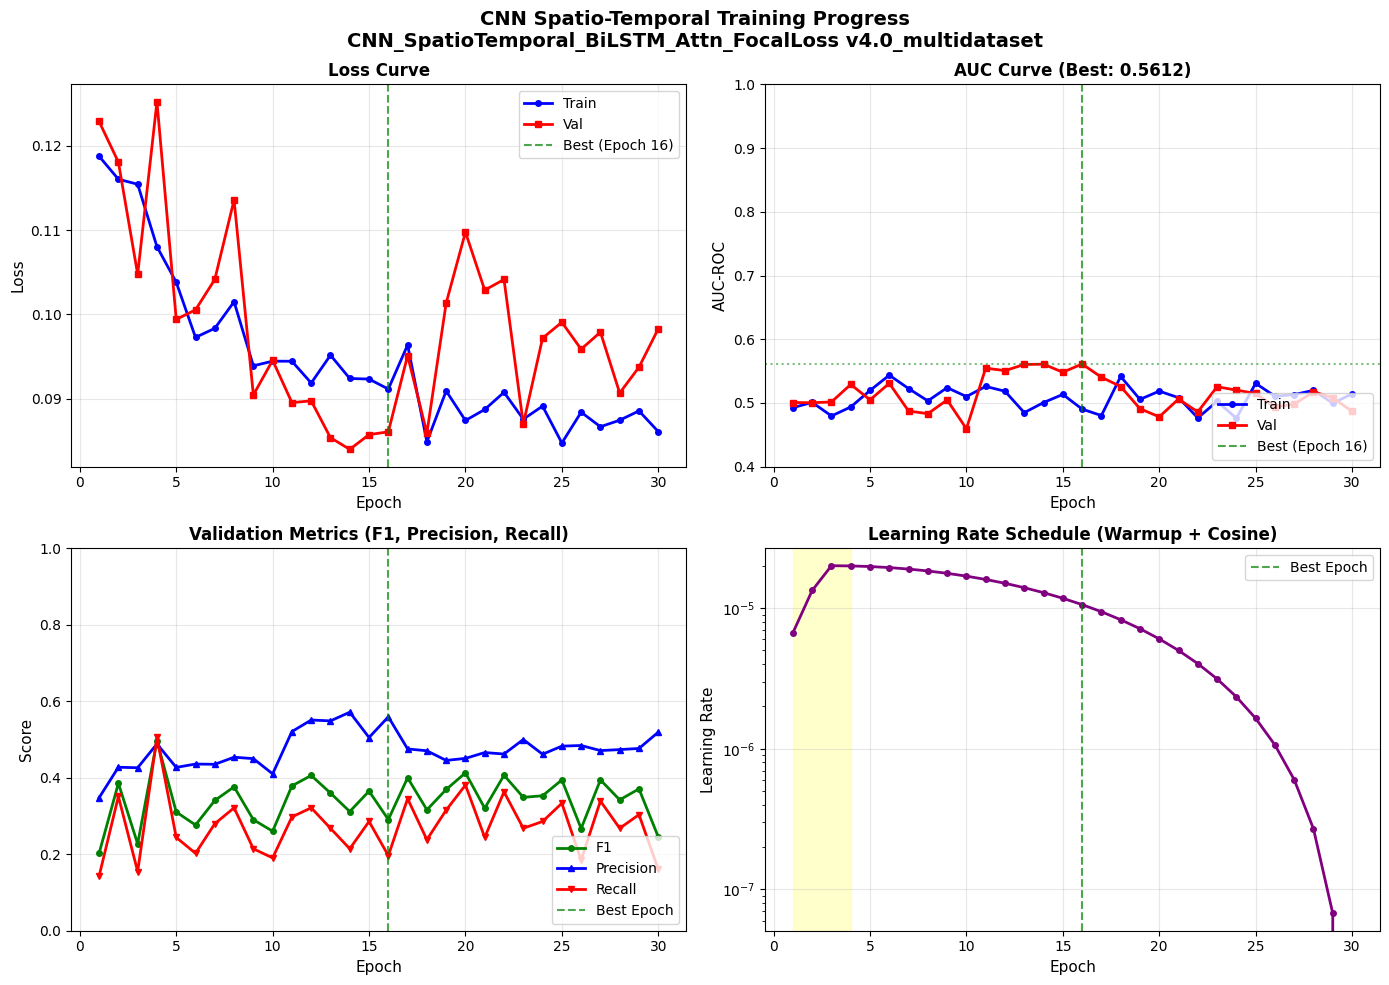

In [34]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRAINING CURVES (Research-Grade Visualization))
# ═══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs = range(1, len(history['train_loss']) + 1)

# 1. Loss Curve
axes[0, 0].plot(epochs, history['train_loss'], 'b-', marker='o', label='Train', linewidth=2, markersize=4)
axes[0, 0].plot(epochs, history['val_loss'], 'r-', marker='s', label='Val', linewidth=2, markersize=4)
axes[0, 0].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best (Epoch {best_epoch})')
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Loss', fontsize=11)
axes[0, 0].set_title('Loss Curve', fontsize=12, fontweight='bold')
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(True, alpha=0.3)

# 2. AUC Curve
axes[0, 1].plot(epochs, history['train_auc'], 'b-', marker='o', label='Train', linewidth=2, markersize=4)
axes[0, 1].plot(epochs, history['val_auc'], 'r-', marker='s', label='Val', linewidth=2, markersize=4)
axes[0, 1].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best (Epoch {best_epoch})')
axes[0, 1].axhline(y=best_val_auc, color='green', linestyle=':', alpha=0.5)
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('AUC-ROC', fontsize=11)
axes[0, 1].set_title(f'AUC Curve (Best: {best_val_auc:.4f})', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0.4, 1.0])

# 3. F1 / Precision / Recall
axes[1, 0].plot(epochs, history['val_f1'], 'g-', marker='o', label='F1', linewidth=2, markersize=4)
axes[1, 0].plot(epochs, history['val_precision'], 'b-', marker='^', label='Precision', linewidth=2, markersize=4)
axes[1, 0].plot(epochs, history['val_recall'], 'r-', marker='v', label='Recall', linewidth=2, markersize=4)
axes[1, 0].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch')
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel('Score', fontsize=11)
axes[1, 0].set_title('Validation Metrics (F1, Precision, Recall)', fontsize=12, fontweight='bold')
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0.0, 1.0])

# 4. Learning Rate Schedule
axes[1, 1].plot(epochs, history['lr'], 'purple', marker='o', linewidth=2, markersize=4)
axes[1, 1].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch')
axes[1, 1].set_xlabel('Epoch', fontsize=11)
axes[1, 1].set_ylabel('Learning Rate', fontsize=11)
axes[1, 1].set_title('Learning Rate Schedule (Warmup + Cosine)', fontsize=12, fontweight='bold')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(loc='upper right')

# Add warmup region annotation
if len(history['lr']) > 1:
    warmup_end_epoch = int(cfg.WARMUP_RATIO * cfg.NUM_EPOCHS) + 1
    if warmup_end_epoch > 0 and warmup_end_epoch < len(epochs):
        axes[1, 1].axvspan(1, warmup_end_epoch, alpha=0.2, color='yellow', label='Warmup Phase')

plt.suptitle(f'CNN Spatio-Temporal Training Progress\n{cfg.EXPERIMENT_NAME} {cfg.EXPERIMENT_VERSION}', 
             fontsize=14, fontweight='bold')
plt.tight_layout()

# Save figure
fig_path = os.path.join(cfg.OUTPUT_DIR, f'training_curves_fold{cfg.CURRENT_FOLD}.png' if cfg.CURRENT_FOLD >= 0 else 'training_curves.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight', facecolor='white')
print(f"✓ Training curves saved to: {fig_path}")

plt.show()


## 6. Video-Level Inference & Export

In [35]:
# ═══════════════════════════════════════════════════════════════════════
# LOAD BEST MODEL
# ═══════════════════════════════════════════════════════════════════════

possible_names = [
    f"best_cnn_model_fold{cfg.CURRENT_FOLD}.pth" if cfg.CURRENT_FOLD >= 0 else "",
    "best_cnn_model.pth",
]

model_path = None
for name in possible_names:
    if not name:
        continue
    temp = os.path.join(cfg.OUTPUT_DIR, name)
    if os.path.exists(temp):
        model_path = temp
        break

if model_path is None:
    pth_files = [f for f in os.listdir(cfg.OUTPUT_DIR) if f.endswith('.pth')]
    if pth_files:
        model_path = os.path.join(cfg.OUTPUT_DIR, pth_files[0])
    else:
        raise FileNotFoundError("No .pth model found. Run training cell first.")

model.load_state_dict(torch.load(model_path, map_location=DEVICE, weights_only=True))
model.eval()
print(f"✓ Best model loaded from: {model_path}")

✓ Best model loaded from: /kaggle/working/best_cnn_model_fold0.pth


In [36]:
def predict_video_temporal(model, cache_path: str, transform,
                            device, max_frames=20):
    """Predict deepfake probability — loads faces from disk."""
    model.eval()

    if not os.path.exists(cache_path):
        return 0.5

    faces = np.load(cache_path)  # (T, H, W, 3)

    if len(faces) < 3:
        return 0.5

    n       = len(faces)
    step    = n / max_frames if n >= max_frames else 1
    indices = [int(i * step) for i in range(max_frames)] \
              if n >= max_frames else list(range(n))
    while len(indices) < max_frames:
        indices.append(n - 1)

    selected     = [faces[i].astype('uint8') for i in indices]
    frame_tensors = [transform(image=f)['image'] for f in selected]
    frames        = torch.stack(frame_tensors).unsqueeze(0).to(device)
    mask          = torch.ones(1, max_frames,
                               dtype=torch.bool).to(device)

    with torch.no_grad():
        logit = model(frames, mask)
        prob  = torch.sigmoid(logit).item()

    del faces
    return prob


def generate_video_predictions(model, videos, cache_index,
                                transform, device):
    """Generate predictions for all videos using disk cache."""
    predictions = []

    for video in tqdm(videos, desc="Predicting"):
        vid_id = video['video_id']
        if vid_id in cache_index:
            prob = predict_video_temporal(
                model, cache_index[vid_id],
                transform, device, cfg.FRAMES_PER_VIDEO)
        else:
            prob = 0.5
        predictions.append({
            'video_id'       : vid_id,
            'label'          : video['label'],
            'prediction'     : prob,
            'predicted_class': 1 if prob > 0.5 else 0,
            'source'         : video.get('source', 'unknown')
        })

    return predictions

print("✓ Prediction functions updated for disk-based cache")

✓ Prediction functions updated for disk-based cache


In [37]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1: EXECUTE VIDEO-LEVEL PREDICTIONS (MUST RUN FIRST)
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("GENERATING FINAL VIDEO-LEVEL PREDICTIONS")
print("="*70)

# 1. Load the best model weights
best_model_path = os.path.join(
    cfg.OUTPUT_DIR,
    f"best_cnn_model_fold{cfg.CURRENT_FOLD}.pth"
    if cfg.CURRENT_FOLD >= 0 else "best_cnn_model.pth"
)
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location=DEVICE, weights_only=True))
    #                                 ^^^^^^^^^^^^^^^ FIXED: use best_model_path, not model_path
    print(f"✓ Loaded best model from: {best_model_path}")
else:
    print(f"⚠️ No saved model found at {best_model_path}, using current model state")

# 2. Generate predictions
model.eval()
raw_preds = generate_video_predictions(model, val_videos, cache_index, get_val_transforms(), DEVICE)

# 3. Create predictions DataFrame (CRITICAL - used by all subsequent cells)
predictions_df = pd.DataFrame(raw_preds)
predictions_df.rename(columns={'prediction': 'P_CNN'}, inplace=True)

# 4. Create the metric variables
y_true = predictions_df['label'].values
y_pred_proba = predictions_df['P_CNN'].values
y_pred = (y_pred_proba > 0.5).astype(int)

# 5. Calculate basic metrics
video_acc = accuracy_score(y_true, y_pred)
video_f1 = f1_score(y_true, y_pred, zero_division=0)
video_precision = precision_score(y_true, y_pred, zero_division=0)
video_recall = recall_score(y_true, y_pred, zero_division=0)

if len(np.unique(y_true)) > 1:
    video_auc = roc_auc_score(y_true, y_pred_proba)
    video_eer = compute_eer(y_true, y_pred_proba)
else:
    video_auc = 0.5
    video_eer = 0.5
    print("⚠️ Single class in validation set - AUC/EER defaulted to 0.5")

# 6. Find optimal threshold
optimal_thresh, optimal_f1 = find_optimal_threshold(y_true, y_pred_proba)
y_pred_optimal = (y_pred_proba >= optimal_thresh).astype(int)
video_acc_optimal = accuracy_score(y_true, y_pred_optimal)
video_f1_optimal = f1_score(y_true, y_pred_optimal, zero_division=0)

# 7. Save predictions
csv_path = os.path.join(cfg.OUTPUT_DIR, "cnn_predictions.csv")
predictions_df.to_csv(csv_path, index=False)

print(f"\n✓ Predictions saved to: {csv_path}")
print(f"  Videos predicted: {len(predictions_df)}")
print(f"\n{'─'*50}")
print("METRICS (threshold=0.5):")
print(f"  AUC-ROC:   {video_auc:.4f}")
print(f"  Accuracy:  {video_acc:.4f}")
print(f"  F1-Score:  {video_f1:.4f}")
print(f"  Precision: {video_precision:.4f}")
print(f"  Recall:    {video_recall:.4f}")
print(f"  EER:       {video_eer:.4f}")
print(f"\n{'─'*50}")
print(f"OPTIMAL THRESHOLD = {optimal_thresh:.2f}:")
print(f"  Accuracy:  {video_acc_optimal:.4f}")
print(f"  F1-Score:  {video_f1_optimal:.4f}")


GENERATING FINAL VIDEO-LEVEL PREDICTIONS
✓ Loaded best model from: /kaggle/working/best_cnn_model_fold0.pth


Predicting:   0%|          | 0/367 [00:00<?, ?it/s]


✓ Predictions saved to: /kaggle/working/cnn_predictions.csv
  Videos predicted: 367

──────────────────────────────────────────────────
METRICS (threshold=0.5):
  AUC-ROC:   0.5612
  Accuracy:  0.5613
  F1-Score:  0.2907
  Precision: 0.5593
  Recall:    0.1964
  EER:       0.4925

──────────────────────────────────────────────────
OPTIMAL THRESHOLD = 0.20:
  Accuracy:  0.5041
  F1-Score:  0.6316


In [38]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 2: BOOTSTRAP CONFIDENCE INTERVALS (Research Requirement)
# ═══════════════════════════════════════════════════════════════════════════════

def bootstrap_ci(y_true, y_pred, metric_fn, n_bootstrap=1000, ci=95, seed=42):
    """Compute bootstrap confidence intervals for a metric."""
    rng = np.random.RandomState(seed)
    n = len(y_true)
    scores = []
    for _ in range(n_bootstrap):
        indices = rng.randint(0, n, n)
        y_true_boot = y_true[indices]
        y_pred_boot = y_pred[indices]
        if len(np.unique(y_true_boot)) < 2:
            continue
        try:
            scores.append(metric_fn(y_true_boot, y_pred_boot))
        except Exception:
            continue
    if len(scores) == 0:
        point = metric_fn(y_true, y_pred)
        return point, point, point
    scores = np.array(scores)
    alpha = (100 - ci) / 2
    return np.percentile(scores, alpha), metric_fn(y_true, y_pred), np.percentile(scores, 100 - alpha)

print("\n" + "="*70)
print("BOOTSTRAP CONFIDENCE INTERVALS (1000 iterations)")
print("="*70)

auc_low, auc_mid, auc_high = bootstrap_ci(y_true, y_pred_proba, roc_auc_score)
acc_low, acc_mid, acc_high = bootstrap_ci(y_true, y_pred, accuracy_score)
f1_low, f1_mid, f1_high   = bootstrap_ci(y_true, y_pred, f1_score)
# FIXED: EER now also has bootstrap CI
eer_low, eer_mid, eer_high = bootstrap_ci(y_true, y_pred_proba, compute_eer)

print(f"\n  AUC-ROC:   {auc_mid:.4f} [95% CI: {auc_low:.4f}, {auc_high:.4f}]")
print(f"  Accuracy:  {acc_mid:.4f} [95% CI: {acc_low:.4f}, {acc_high:.4f}]")
print(f"  F1-Score:  {f1_mid:.4f} [95% CI: {f1_low:.4f}, {f1_high:.4f}]")
print(f"  EER:       {eer_mid:.4f} [95% CI: {eer_low:.4f}, {eer_high:.4f}]")

# Save metrics with CI — all 4 metrics now have intervals
metrics_df = pd.DataFrame([
    {'metric': 'AUC-ROC',  'value': auc_mid,  'ci_low': auc_low,  'ci_high': auc_high},
    {'metric': 'Accuracy', 'value': acc_mid,  'ci_low': acc_low,  'ci_high': acc_high},
    {'metric': 'F1-Score', 'value': f1_mid,   'ci_low': f1_low,   'ci_high': f1_high},
    {'metric': 'EER',      'value': eer_mid,  'ci_low': eer_low,  'ci_high': eer_high},
])
metrics_df.to_csv(os.path.join(cfg.OUTPUT_DIR, "cnn_metrics_with_ci.csv"), index=False)
print(f"\n✓ Metrics with 95% CI saved to: cnn_metrics_with_ci.csv")


BOOTSTRAP CONFIDENCE INTERVALS (1000 iterations)

  AUC-ROC:   0.5612 [95% CI: 0.5038, 0.6213]
  Accuracy:  0.5613 [95% CI: 0.5123, 0.6131]
  F1-Score:  0.2907 [95% CI: 0.2146, 0.3684]
  EER:       0.4925 [95% CI: 0.4299, 0.5337]

✓ Metrics with 95% CI saved to: cnn_metrics_with_ci.csv


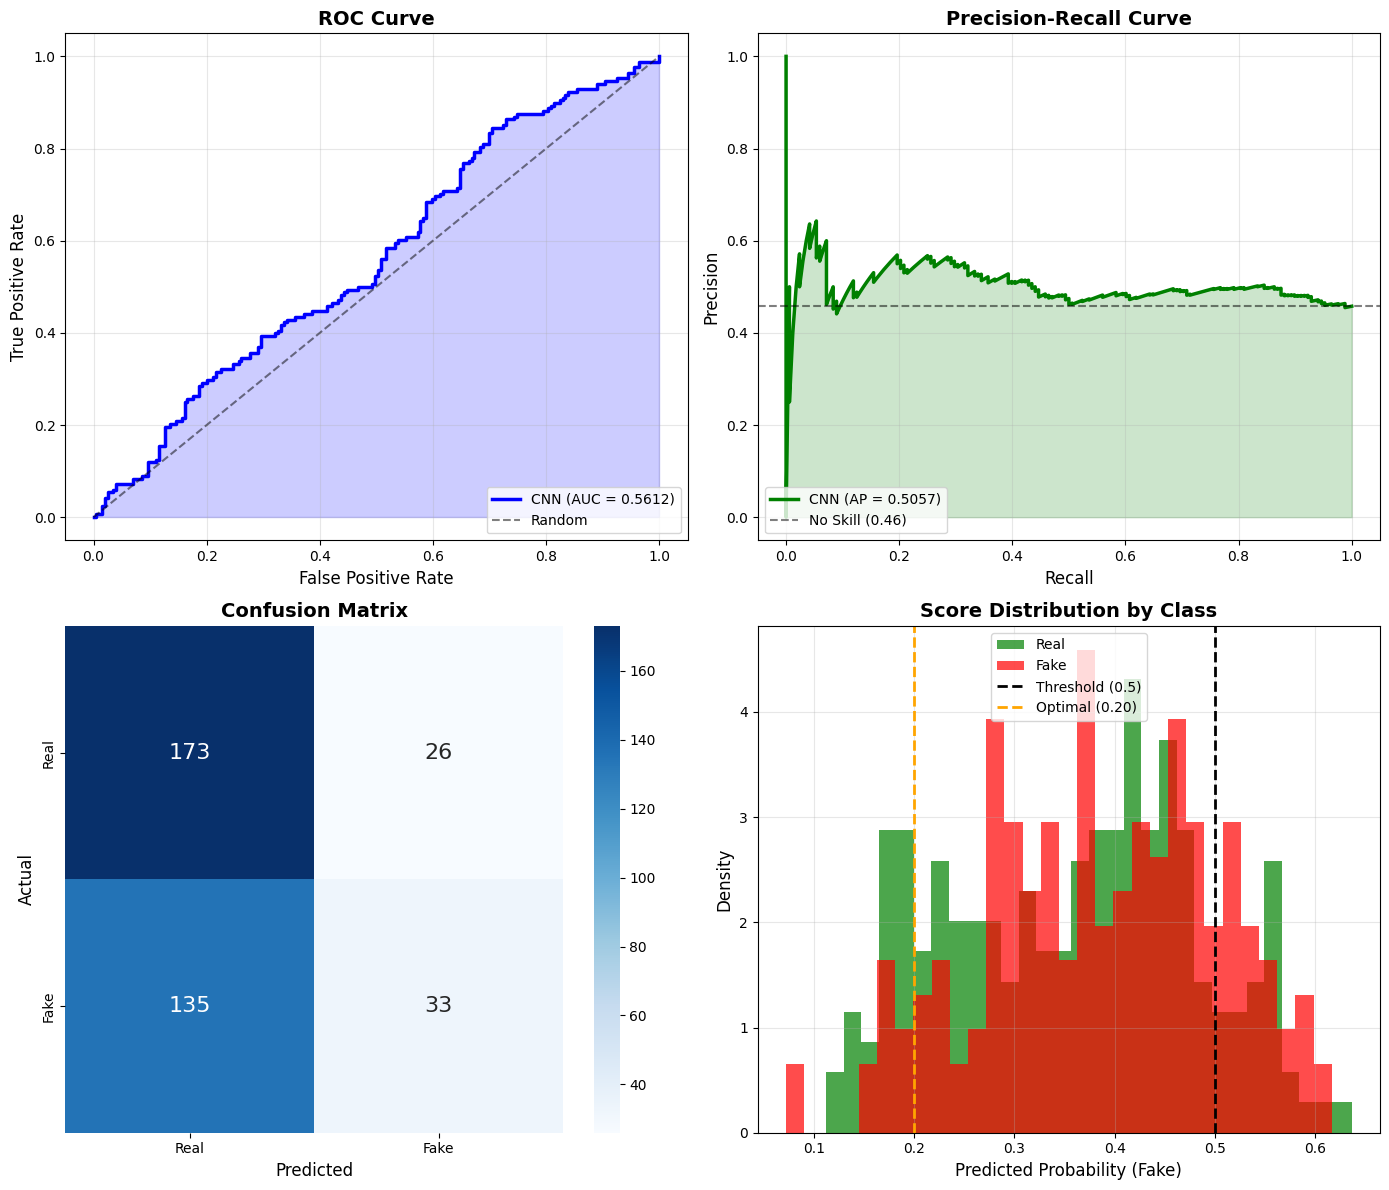


✓ Evaluation plots saved to: cnn_evaluation_plots.png

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Real     0.5617    0.8693    0.6824       199
        Fake     0.5593    0.1964    0.2907       168

    accuracy                         0.5613       367
   macro avg     0.5605    0.5329    0.4866       367
weighted avg     0.5606    0.5613    0.5031       367



In [39]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 3: RESEARCH-GRADE VISUALIZATIONS
# ═══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score, roc_curve
import seaborn as sns

# Prepare data
real_preds = predictions_df[predictions_df['label'] == 0]['P_CNN']
fake_preds = predictions_df[predictions_df['label'] == 1]['P_CNN']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
axes[0, 0].plot(fpr, tpr, 'b-', linewidth=2.5, label=f'CNN (AUC = {video_auc:.4f})')
axes[0, 0].fill_between(fpr, tpr, alpha=0.2, color='blue')
axes[0, 0].plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1.5, label='Random')
axes[0, 0].set_xlabel('False Positive Rate', fontsize=12)
axes[0, 0].set_ylabel('True Positive Rate', fontsize=12)
axes[0, 0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(True, alpha=0.3)

# 2. Precision-Recall Curve
precision_arr, recall_arr, _ = precision_recall_curve(y_true, y_pred_proba)
ap = average_precision_score(y_true, y_pred_proba)
axes[0, 1].plot(recall_arr, precision_arr, 'g-', linewidth=2.5, label=f'CNN (AP = {ap:.4f})')
axes[0, 1].fill_between(recall_arr, precision_arr, alpha=0.2, color='green')
axes[0, 1].axhline(y=y_true.mean(), color='k', linestyle='--', alpha=0.5, label=f'No Skill ({y_true.mean():.2f})')
axes[0, 1].set_xlabel('Recall', fontsize=12)
axes[0, 1].set_ylabel('Precision', fontsize=12)
axes[0, 1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[0, 1].legend(loc='lower left')
axes[0, 1].grid(True, alpha=0.3)

# 3. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
            annot_kws={'size': 16})
axes[1, 0].set_xlabel('Predicted', fontsize=12)
axes[1, 0].set_ylabel('Actual', fontsize=12)
axes[1, 0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# 4. Score Distribution
axes[1, 1].hist(real_preds, bins=30, alpha=0.7, label='Real', color='green', density=True)
axes[1, 1].hist(fake_preds, bins=30, alpha=0.7, label='Fake', color='red', density=True)
axes[1, 1].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')
axes[1, 1].axvline(x=optimal_thresh, color='orange', linestyle='--', linewidth=2, label=f'Optimal ({optimal_thresh:.2f})')
axes[1, 1].set_xlabel('Predicted Probability (Fake)', fontsize=12)
axes[1, 1].set_ylabel('Density', fontsize=12)
axes[1, 1].set_title('Score Distribution by Class', fontsize=14, fontweight='bold')
axes[1, 1].legend(loc='upper center')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'cnn_evaluation_plots.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Evaluation plots saved to: cnn_evaluation_plots.png")

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=['Real', 'Fake'], digits=4))



GENERATING GRAD-CAM VISUALIZATIONS


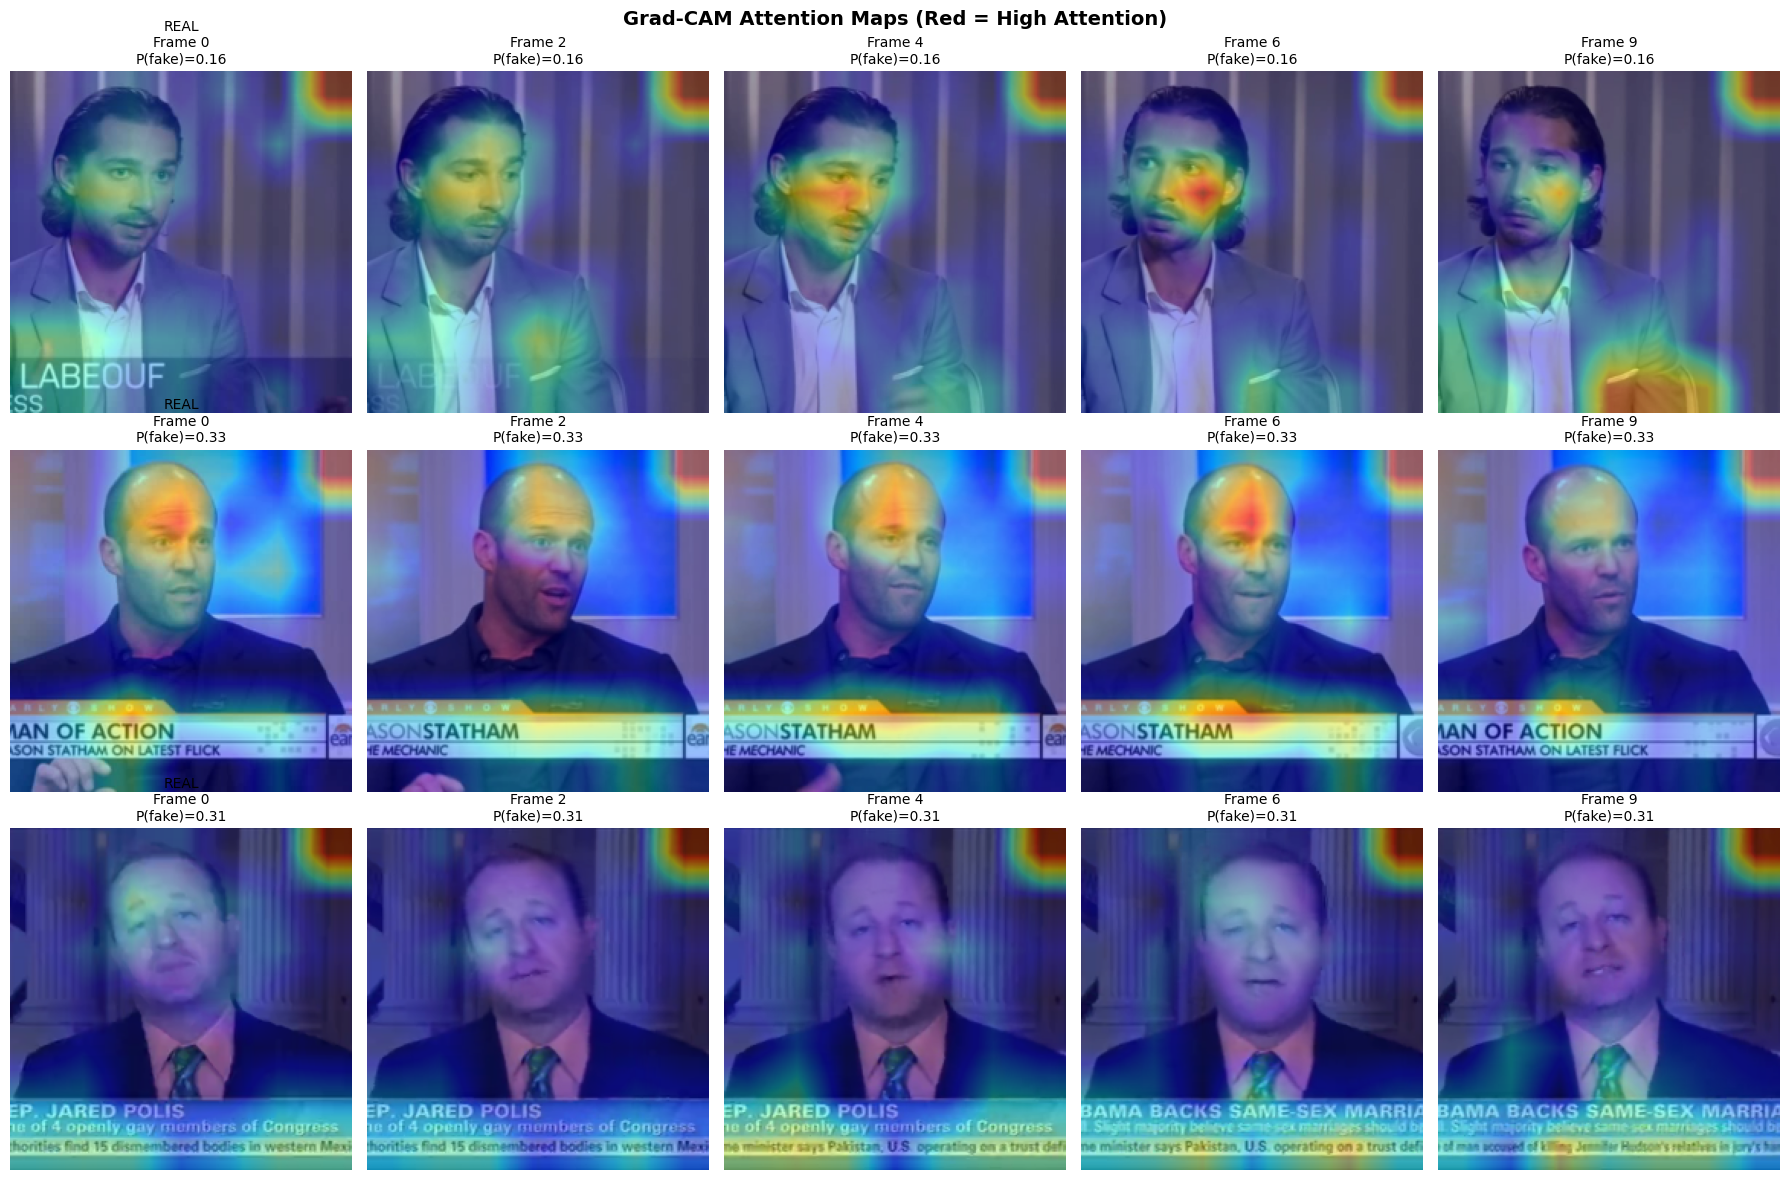


✓ Grad-CAM visualization saved: gradcam_gallery.png
  Videos shown: 3 of 3 available


In [40]:
# ═══════════════════════════════════════════════════════════════════════
# STEP 4: GRAD-CAM VISUALIZATION (Research Requirement)
# Fixed: uses cache_index (not face_data), 20 frames, P100-safe numpy
# ═══════════════════════════════════════════════════════════════════════

import torch.nn.functional as F

class SimpleGradCAM:
    """Grad-CAM for temporal models — P100 safe."""
    
    def __init__(self, cnn_model):
        self.model      = cnn_model
        self.gradients  = None
        self.activations = None
        self.handles    = []
        target_layer    = self.model.backbone.conv_head
        self.handles.append(target_layer.register_forward_hook(self._save_activation))
        self.handles.append(target_layer.register_full_backward_hook(self._save_gradient))

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def cleanup(self):
        for h in self.handles:
            h.remove()
        self.handles = []

    def generate(self, frames, mask, target_frame_idx=0):
        self.model.eval()

        logit = self.model(frames, mask)
        prob = torch.sigmoid(logit).detach().item()

        self.model.zero_grad()
        logit.squeeze().backward(retain_graph=True)

        if self.gradients is None or self.activations is None:
            return np.zeros(frames.shape[3:]), prob

        target_grads = self.gradients[target_frame_idx:target_frame_idx + 1]
        target_acts  = self.activations[target_frame_idx:target_frame_idx + 1]

        weights = target_grads.mean(dim=(2, 3), keepdim=True)
        cam     = F.relu((weights * target_acts).sum(dim=1, keepdim=True))

        if cam.max() - cam.min() > 1e-8:
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        else:
            cam = torch.zeros_like(cam)

        cam = F.interpolate(cam, size=frames.shape[3:],
                            mode='bilinear', align_corners=False)

        # P100 FIX: use .tolist() NOT .numpy() — avoids C-API crash
        cam_numpy = np.array(cam.squeeze().cpu().tolist())
        return cam_numpy, prob


print("\n" + "="*70)
print("GENERATING GRAD-CAM VISUALIZATIONS")
print("="*70)



gradcam = SimpleGradCAM(model)

# Collect up to 3 valid videos first, THEN draw the figure
valid_videos_for_gradcam = []
for video in val_videos:
    if len(valid_videos_for_gradcam) >= 3:
        break
    vid_id = video['video_id']
    if vid_id not in cache_index:
        continue
    faces_check = np.load(cache_index[vid_id])
    if len(faces_check) < 5:
        del faces_check
        continue
    valid_videos_for_gradcam.append(video)
    del faces_check

n_videos_to_show = len(valid_videos_for_gradcam)
frame_indices = [0, 2, 4, 6, 9]  # 5 frames from 20-frame sequence

if n_videos_to_show == 0:
    print("⚠️  WARNING: No valid videos found for Grad-CAM visualization.")
    print("   Possible causes: cache_index empty, all videos have <5 faces.")
    gradcam.cleanup()
else:
    # Create figure with EXACT number of rows needed — no blank rows
    fig, axes = plt.subplots(n_videos_to_show, 5,
                              figsize=(18, 4 * n_videos_to_show))
    # Ensure axes is always 2D even when n_videos_to_show == 1
    if n_videos_to_show == 1:
        axes = axes[np.newaxis, :]

    videos_shown = 0
    for video in valid_videos_for_gradcam:
        vid_id = video['video_id']
        faces  = np.load(cache_index[vid_id])
        label  = video['label']

        n_faces = len(faces)
        if n_faces >= cfg.FRAMES_PER_VIDEO:
            step    = n_faces / cfg.FRAMES_PER_VIDEO
            indices = [int(i * step) for i in range(cfg.FRAMES_PER_VIDEO)]
        else:
            indices = list(range(n_faces))
            while len(indices) < cfg.FRAMES_PER_VIDEO:
                indices.append(n_faces - 1)

        selected_faces = [faces[i].astype('uint8') for i in indices]

        val_tf = get_val_transforms()
        frame_tensors = [val_tf(image=face)['image'] for face in selected_faces]

        input_frames = torch.stack(frame_tensors).unsqueeze(0).to(DEVICE)
        input_mask   = torch.ones(1, cfg.FRAMES_PER_VIDEO,
                                  dtype=torch.bool).to(DEVICE)

        for col, f_idx in enumerate(frame_indices):
            heatmap, prob = gradcam.generate(
                input_frames.clone(), input_mask, target_frame_idx=f_idx)

            face_img = selected_faces[f_idx]
            axes[videos_shown, col].imshow(face_img)
            axes[videos_shown, col].imshow(heatmap, cmap='jet', alpha=0.4)

            title = f"Frame {f_idx}\nP(fake)={prob:.2f}"
            if col == 0:
                title = f"{'FAKE' if label==1 else 'REAL'}\n{title}"
            axes[videos_shown, col].set_title(title, fontsize=10)
            axes[videos_shown, col].axis('off')

        del faces
        videos_shown += 1

    gradcam.cleanup()

    plt.suptitle('Grad-CAM Attention Maps (Red = High Attention)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'gradcam_gallery.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✓ Grad-CAM visualization saved: gradcam_gallery.png")
    print(f"  Videos shown: {videos_shown} of {n_videos_to_show} available")

## 7. Late Fusion Integration Guide

In [41]:
# ═══════════════════════════════════════════════════════════════════════════════
# LATE FUSION INTEGRATION GUIDE
# ═══════════════════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                       LATE FUSION INTEGRATION GUIDE                          ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  This notebook outputs: cnn_predictions.csv                                  ║
║  Columns: video_id, P_CNN                                                    ║
║                                                                              ║
║  To fuse with rPPG predictions from 2ND_MODEL.ipynb:                        ║
║                                                                              ║
║  ┌─────────────────────────────────────────────────────────────────────────┐ ║
║  │  # Load both predictions                                                │ ║
║  │  cnn_df = pd.read_csv('cnn_predictions.csv')                           │ ║
║  │  rppg_df = pd.read_csv('rppg_predictions.csv')                         │ ║
║  │                                                                         │ ║
║  │  # Merge on video_id                                                    │ ║
║  │  fused_df = cnn_df.merge(rppg_df, on='video_id')                       │ ║
║  │                                                                         │ ║
║  │  # Simple average fusion                                                │ ║
║  │  fused_df['P_final'] = (fused_df['P_CNN'] + fused_df['P_rPPG']) / 2    │ ║
║  │                                                                         │ ║
║  │  # Weighted fusion (if CNN is more accurate)                           │ ║
║  │  w_cnn, w_rppg = 0.6, 0.4                                              │ ║
║  │  fused_df['P_final'] = w_cnn * fused_df['P_CNN']                       │ ║
║  │                      + w_rppg * fused_df['P_rPPG']                      │ ║
║  │                                                                         │ ║
║  │  # Learned fusion (train a small classifier)                           │ ║
║  │  from sklearn.linear_model import LogisticRegression                   │ ║
║  │  X_fusion = fused_df[['P_CNN', 'P_rPPG']].values                       │ ║
║  │  y_fusion = fused_df['label'].values                                   │ ║
║  │  fusion_model = LogisticRegression().fit(X_fusion, y_fusion)           │ ║
║  │  fused_df['P_final'] = fusion_model.predict_proba(X_fusion)[:, 1]      │ ║
║  └─────────────────────────────────────────────────────────────────────────┘ ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║                       LATE FUSION INTEGRATION GUIDE                          ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  This notebook outputs: cnn_predictions.csv                                  ║
║  Columns: video_id, P_CNN                                                    ║
║                                                                              ║
║  To fuse with rPPG predictions from 2ND_MODEL.ipynb:                        ║
║                                                                              ║
║  ┌─────────────────────────────────────────────────────────────────────────┐ ║
║  │  # Load both predictions                                                │ ║
║  │  cnn_df = pd.read_csv('cnn_predictions.csv')                           │ ║
║  │  rppg_df = pd.read_csv('

In [42]:
# ═══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("CNN SPATIO-TEMPORAL STREAM — FINAL SUMMARY")
print("="*70)

# Get parameter counts (handle both variable names)
total = total_params if 'total_params' in vars() else sum(p.numel() for p in model.parameters())
trainable_count = trainable if 'trainable' in vars() else sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│  ARCHITECTURE                                                               │
├─────────────────────────────────────────────────────────────────────────────┤
│  Backbone:           EfficientNet-B4 (ImageNet pretrained)                  │
│  Temporal Model:     BiLSTM + Multi-Head Self-Attention                     │
│  LSTM Hidden:        {cfg.LSTM_HIDDEN} × 2 (bidirectional)                                │
│  LSTM Layers:        {cfg.LSTM_LAYERS}                                                     │
│  Attention Heads:    {cfg.ATTENTION_HEADS}                                                     │
│  Total Parameters:   {total:,}                                       │
│  Trainable Params:   {trainable_count:,}                                       │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│  TRAINING CONFIGURATION                                                     │
├─────────────────────────────────────────────────────────────────────────────┤
│  Training Videos:    {len(train_videos)}                                                       │
│  Validation Videos:  {len(val_videos)}                                                       │
│  Frames per Video:   {cfg.FRAMES_PER_VIDEO}                                                        │
│  Batch Size:         {cfg.BATCH_SIZE} (effective: {cfg.BATCH_SIZE * cfg.GRAD_ACCUMULATION_STEPS})                                         │
│  Learning Rate:      {cfg.LEARNING_RATE}                                                    │
│  Loss Function:      Focal Loss (α={cfg.FOCAL_ALPHA}, γ={cfg.FOCAL_GAMMA})                              │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│  BEST FRAME-LEVEL RESULTS                                                   │
├─────────────────────────────────────────────────────────────────────────────┤
│  Best Epoch:         {best_epoch}                                                        │
│  Best Val AUC:       {best_val_auc:.4f}                                                    │
│  Best Val EER:       {best_val_eer:.4f}                                                    │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│  VIDEO-LEVEL METRICS (Final Evaluation)                                     │
├─────────────────────────────────────────────────────────────────────────────┤
│  AUC-ROC:            {video_auc:.4f}                                                    │
│  Accuracy:           {video_acc:.4f}                                                    │
│  F1-Score:           {video_f1:.4f}                                                    │
│  EER:                {video_eer:.4f}                                                    │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│  OUTPUT FILES                                                               │
├─────────────────────────────────────────────────────────────────────────────┤
│  ✓ cnn_predictions.csv          (video-level P_CNN scores for Late Fusion) │
│  ✓ best_cnn_model.pth           (best checkpoint weights)                  │
│  ✓ cnn_spatial_stream_final.pth (final model weights)                      │
│  ✓ cnn_training_history.csv     (epoch-by-epoch metrics)                   │
│  ✓ cnn_config.csv               (hyperparameters & final results)          │
└─────────────────────────────────────────────────────────────────────────────┘
""")


# Save final model weights (distinct from best checkpoint)
final_model_path = os.path.join(cfg.OUTPUT_DIR, "cnn_spatial_stream_final.pth")
torch.save(model.state_dict(), final_model_path)
print(f"✓ Final model saved: {final_model_path}")

# Save config as CSV for paper reproducibility
config_csv_path = os.path.join(cfg.OUTPUT_DIR, "cnn_config.csv")
pd.DataFrame([cfg.to_dict()]).to_csv(config_csv_path, index=False)
print(f"✓ Config saved as CSV: {config_csv_path}")


print("="*70)
print("✅ CNN SPATIO-TEMPORAL STREAM TRAINING COMPLETE!")
print("="*70)
print("\n  Key achievements:")
print("  ✓ Temporal modeling via BiLSTM + Multi-Head Attention")
print("  ✓ Detects inter-frame artifacts (flickering, blending shifts)")
print("  ✓ P100 compatible (FP32 only, no AMP)")
print("  ✓ Ready for Late Fusion with rPPG physiological stream")
print("\n  Next step:")
print("  → Run final_MODEL_rppg.ipynb to get P_rPPG scores")
print("  → Combine P_CNN + P_rPPG for Late Fusion ensemble")
print("="*70)




CNN SPATIO-TEMPORAL STREAM — FINAL SUMMARY

┌─────────────────────────────────────────────────────────────────────────────┐
│  ARCHITECTURE                                                               │
├─────────────────────────────────────────────────────────────────────────────┤
│  Backbone:           EfficientNet-B4 (ImageNet pretrained)                  │
│  Temporal Model:     BiLSTM + Multi-Head Self-Attention                     │
│  LSTM Hidden:        256 × 2 (bidirectional)                                │
│  LSTM Layers:        2                                                     │
│  Attention Heads:    4                                                     │
│  Total Parameters:   24,540,745                                       │
│  Trainable Params:   24,540,745                                       │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│  TRAIN

In [44]:
import os
import shutil

# Folder to collect outputs
output_dir = "/kaggle/working/final_output"
os.makedirs(output_dir, exist_ok=True)

# Copy everything except unwanted folders/files
for item in os.listdir("/kaggle/working"):
    if item in ["face_cache", "final_output", "final_output.zip"]:
        continue  # skip these

    src = os.path.join("/kaggle/working", item)
    dst = os.path.join(output_dir, item)

    try:
        if os.path.isdir(src):
            shutil.copytree(src, dst)
        else:
            shutil.copy2(src, dst)
    except Exception as e:
        print(f"Skipping {item}: {e}")

# Zip it
zip_path = "/kaggle/working/final_output.zip"
shutil.make_archive(zip_path.replace(".zip", ""), 'zip', output_dir)

print("✅ Ready to download:", zip_path)

Skipping .virtual_documents: [Errno 17] File exists: '/kaggle/working/final_output/.virtual_documents'
✅ Ready to download: /kaggle/working/final_output.zip


In [45]:
import os
import zipfile

source_dir = "/kaggle/working/final_output"
zip_base = "/kaggle/working/final_output_part"

max_size = 500 * 1024 * 1024  # 500MB per zip

files = []
for root, dirs, filenames in os.walk(source_dir):
    for f in filenames:
        files.append(os.path.join(root, f))

part = 1
current_size = 0
zipf = zipfile.ZipFile(f"{zip_base}{part}.zip", 'w', zipfile.ZIP_DEFLATED)

for file in files:
    file_size = os.path.getsize(file)

    if current_size + file_size > max_size:
        zipf.close()
        part += 1
        zipf = zipfile.ZipFile(f"{zip_base}{part}.zip", 'w', zipfile.ZIP_DEFLATED)
        current_size = 0

    zipf.write(file, os.path.relpath(file, source_dir))
    current_size += file_size

zipf.close()

print("✅ Split ZIP files ready!")

✅ Split ZIP files ready!


In [46]:
from IPython.display import FileLink
FileLink('/kaggle/working/final_output.zip')

/kaggle/working/final_output.zip

In [61]:
def split_file(file_path, chunk_size=20*1024*1024):  # 20MB parts
    with open(file_path, 'rb') as f:   # ✅ FIXED
        i = 0
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            with open(f"{file_path}.part{i}", 'wb') as out:
                out.write(chunk)
            i += 1

split_file("/kaggle/working/model_fp16.pth")